---


# **--> Análise prévia**


---

In [ ]:
# Importing libraries
import numpy as np
import pandas as pd

# Importing dataset
df = pd.read_excel("/content/Process features - data analysis.xlsx")
df

In [ ]:
# Previous analysis of dataset
df.describe()
df.info()

In [3]:
# Removing column "Bed type"
df1 = df.drop(columns=['Bed type'])

In [4]:
# Removing columns "Porosity" and "Surface area (m²/g)" because entire columns are NAN type
df2 = df1.drop(columns=['Porosity', 'Surface Area (m²/g)'])

In [5]:
# Analyzing just works that performed pellets
df3 = df2.dropna(subset=['esfericity'])

In [6]:
# Removing columns "Ore porosity" and "Ore moisture" - Entire NaN
df4 = df3.drop(columns=['Ore porosity', 'Ore moisture'])

In [7]:
# Removing the first two columns
df5 = df4.drop(columns=['Reference', 'Observations (1 - fixed bed; 2 - fluidized bed)'])

In [ ]:
# Densification temperature is 20°C for all remaining experiments;
# Ore surface area is 3,9 m²/g for all remaining experiments (few experiments report this info);
# Densification time is zero min for all remaining experiments;

In [8]:
df6 = df5.drop(columns=['Ore surface area (m²/g)', 'Densification time (min)', 'Densification temperature (°C)'])
df6 = df6.dropna(subset=['% Reduced iron']) # Removing the NaN values in the "predicted variable"

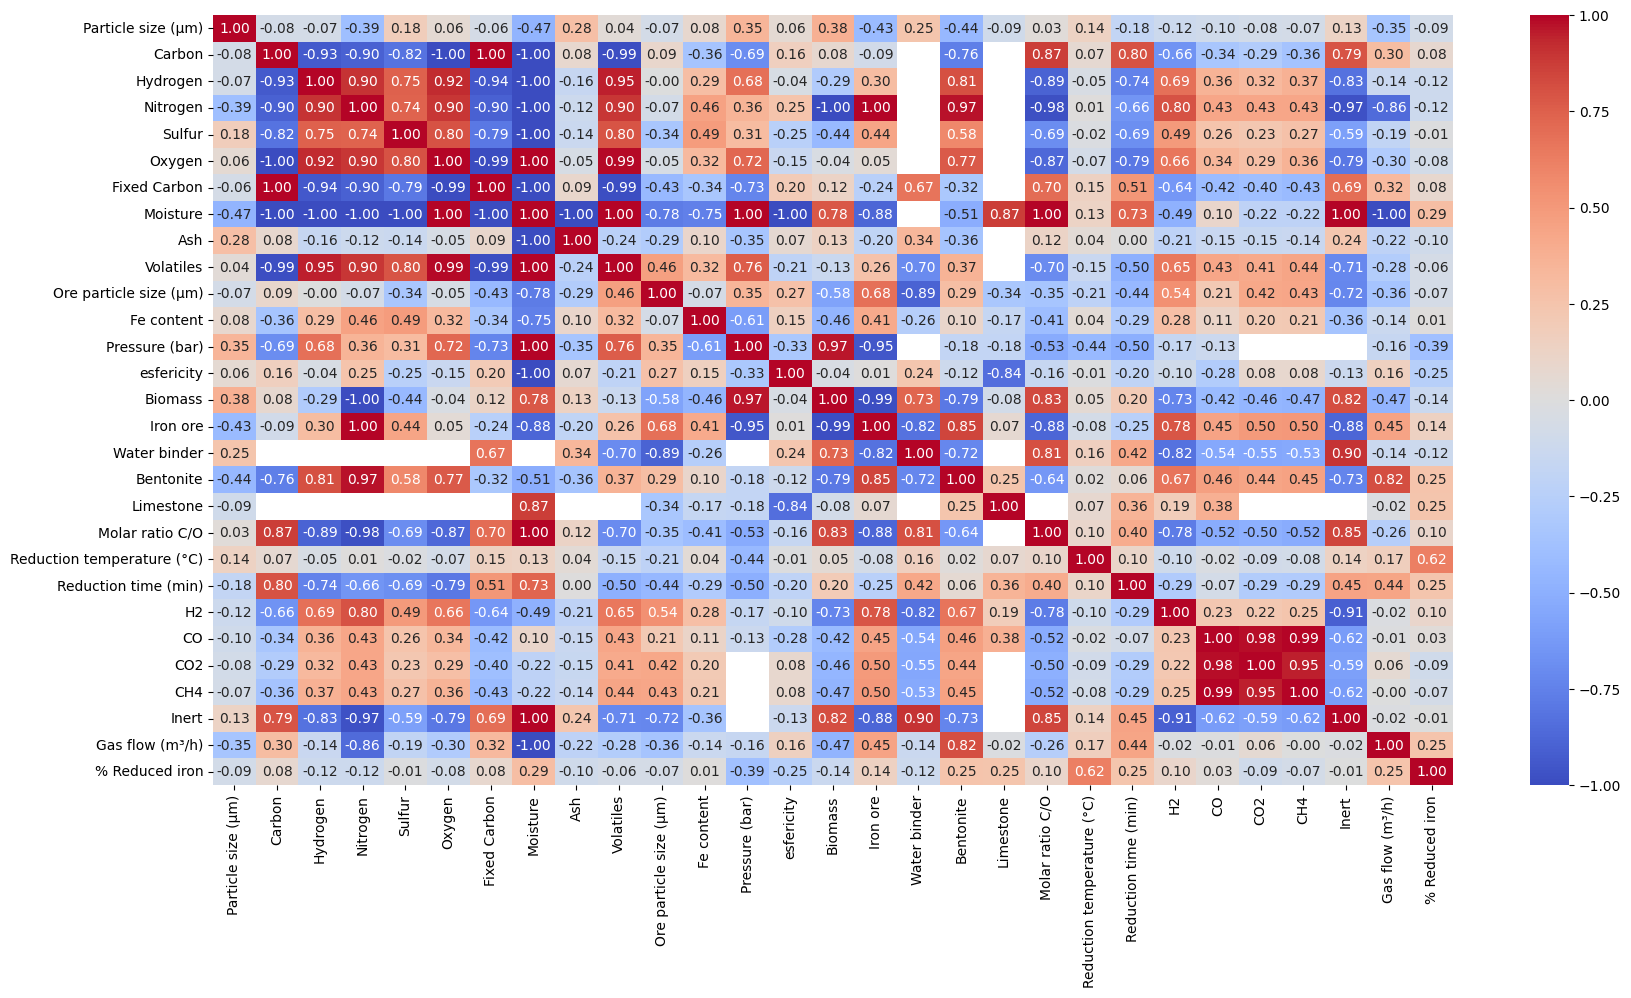

In [9]:
# Correlaction matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df6.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
#plt.title('Correlation Matrix before imputation')
plt.show()

In [11]:
# Removing 'Pressure (bar)' outliers
df7 = df6.drop(outliers.index)

In [ ]:
# Identifying the outliers
import numpy as np
import pandas as pd

# Target feature
target_feature = 'Reduction temperature (°C)'

# Quartis and IQR
Q1 = df7[target_feature].quantile(0.25)
Q3 = df7[target_feature].quantile(0.75)
IQR = Q3 - Q1

# Range for outliers detection
lower_border = Q1 - 1.5 * IQR
upper_border = Q3 + 1.5 * IQR

# Outliers identifying
outliers = df7[
    (df7[target_feature] < lower_border) |
    (df7[target_feature] > upper_border)
]

print(f"--- Outliers analysis for {target_feature} (IQR method) ---")
print(f"Q1 (25º Percentil): {Q1:.2f}")
print(f"Q3 (75º Percentil): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower border: {lower_border:.2f}")
print(f"Upper border: {upper_border:.2f}")
print(f"\nTotal of detected Outliers: {len(outliers)}")
print(f"Outliers percentage: {(len(outliers) / len(df7) * 100):.2f}%")

In [13]:
# Removing 'Reduction temperature (°C)' outliers
df8 = df7.drop(outliers.index)

In [ ]:
# Identifying the outliers
import numpy as np
import pandas as pd

# Target feature
target_feature = 'Particle size (µm)'

# Quartis and IQR
Q1 = df8[target_feature].quantile(0.25)
Q3 = df8[target_feature].quantile(0.75)
IQR = Q3 - Q1

# Range for outliers detection
lower_border = Q1 - 1.5 * IQR
upper_border = Q3 + 1.5 * IQR

# Outliers identifying
outliers = df8[
    (df8[target_feature] < lower_border) |
    (df8[target_feature] > upper_border)
]

print(f"--- Outliers analysis for {target_feature} (IQR method) ---")
print(f"Q1 (25º Percentil): {Q1:.2f}")
print(f"Q3 (75º Percentil): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower border: {lower_border:.2f}")
print(f"Upper border: {upper_border:.2f}")
print(f"\nTotal of detected Outliers: {len(outliers)}")
print(f"Outliers percentage: {(len(outliers) / len(df8) * 100):.2f}%")

In [15]:
# Removing 'Particle size (µm)' outliers
df9 = df8.drop(outliers.index)

In [ ]:
df9.info()

In [ ]:
# Exporting the dataframe
df9.to_excel("df9.xlsx", index=False)

---


# **--> MICE Imputation**


---

In [ ]:
from sklearn.experimental import enable_iterative_imputer # Flag experimental
from sklearn.impute import IterativeImputer # Imputador
from sklearn.linear_model import BayesianRidge # Estimator
from sklearn.ensemble import RandomForestRegressor # Estimator
import pandas as pd
import numpy as np

# Iterative Imputer
imputer_mice = IterativeImputer(
    estimator=RandomForestRegressor(),
    #BayesianRidge(),
    max_iter=20,
    random_state=50
)

# Fit and transform
df10 = imputer_mice.fit_transform(df9)

# Turning to dataframe
df11 = pd.DataFrame(
    df10,
    columns=df9.columns,
    index=df9.index
)

In [ ]:
# Features range
df11.info()

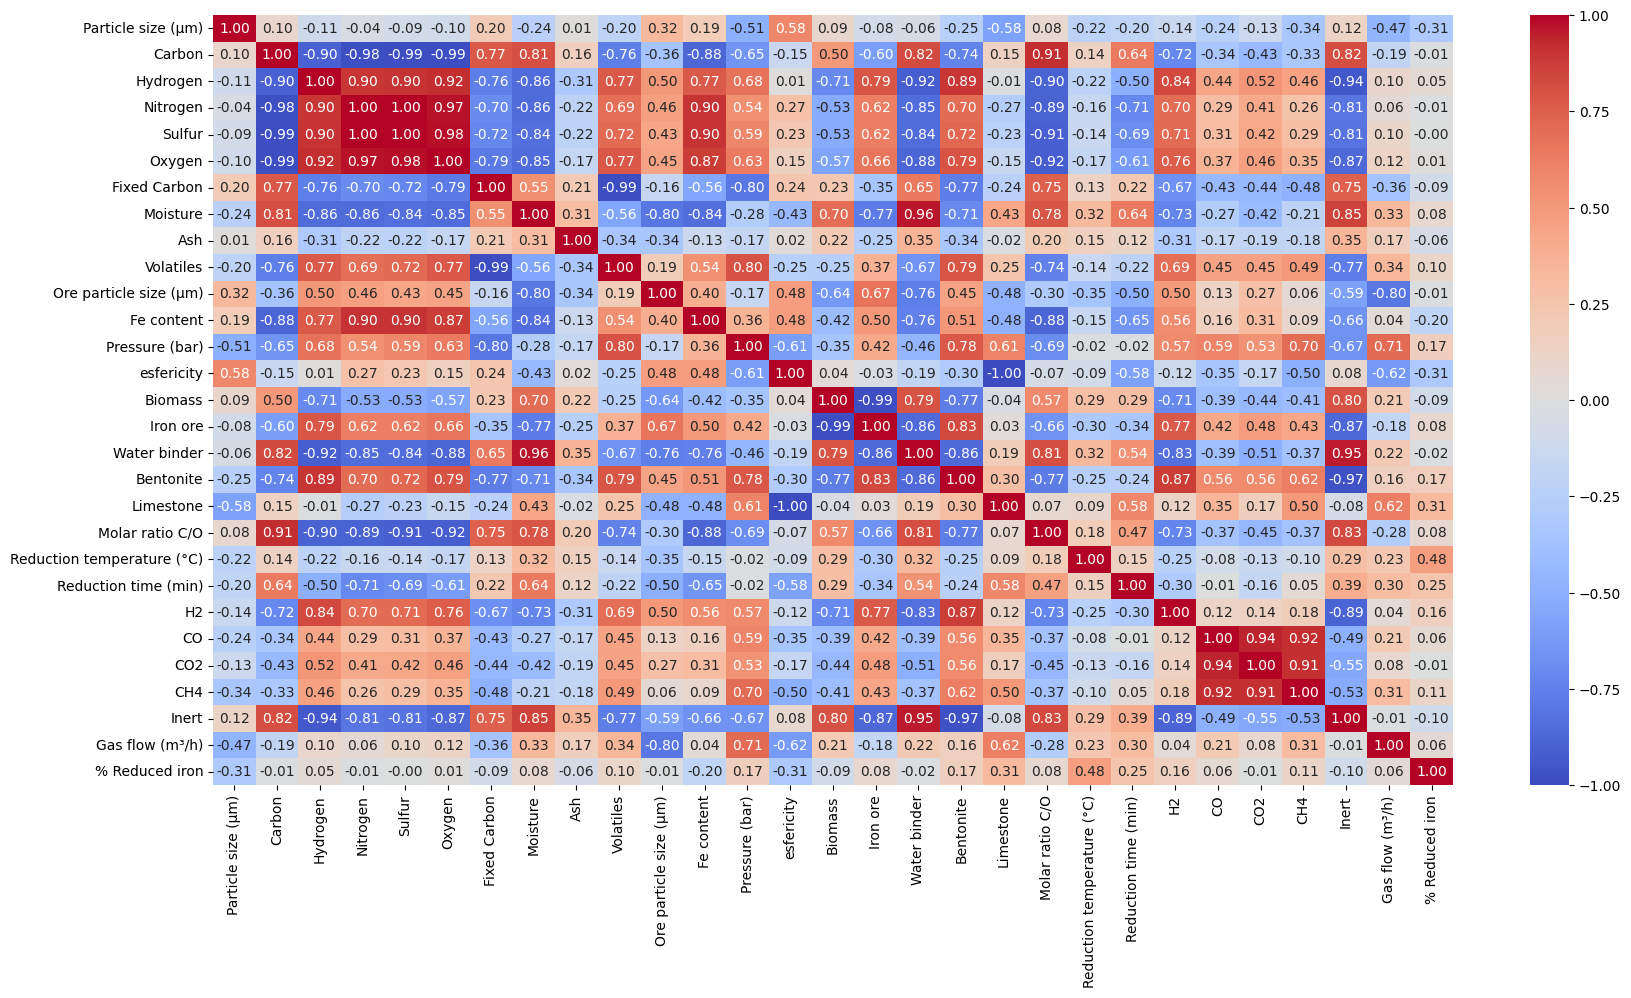

In [ ]:
# Correlaction matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df11.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
#plt.title('Correlation Matrix before imputation')
plt.show()

In [ ]:
# Exporting the dataframe
df11.to_excel("df11_caio.xlsx", index=False)

In [ ]:
# 100% Ultimate Analysis verification
import pandas as pd
import numpy as np

df12 = df11.copy()

# Ultimate analysis
ultimate_columns = ['Carbon', 'Hydrogen', 'Nitrogen', 'Sulfur', 'Oxygen']

df12['Ultimate_sum'] = df12[ultimate_columns].sum(axis=1)
df12['Ultimate_deviation'] = df12['Ultimate_sum'] - 1

deviation_analysis = df12['Ultimate_deviation']

print("\nExtreme deviations (Positives and Negatives):")

max_deviation = 100 * df12['Ultimate_deviation'].max()
min_deviation = 100 * df12['Ultimate_deviation'].min()
print(f"Max positive deviation: +{max_deviation:.2f} %")
print(f"Max negative deviation: {min_deviation:.2f} %")

import matplotlib.pyplot as plt
df12['Ultimate_deviation'].hist(bins=50)
#plt.title("Deviation distribution for 'Ultimate Analysis'")
plt.xlabel("Absolute deviation", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.text(-0.03, 100, 'Ultimate Analysis', fontsize=12, fontweight='bold',
        bbox=dict(
        facecolor='white',
        alpha=0.8,
        edgecolor='black',
        linewidth=1.0,
        boxstyle='round,pad=0.5'
        ))
plt.show()

In [ ]:
# 100% Proximate Analysis verification
import pandas as pd
import numpy as np

df13 = df11.copy()

# Proximate analysis
proximate_columns = ['Fixed Carbon', 'Ash', 'Volatiles']

df13['Proximate_sum'] = df13[proximate_columns].sum(axis=1)
df13['Proximate_deviation'] = df13['Proximate_sum'] - 1

print("--- Statistical analysis - Proximate features ---")

deviation_analysis = df13['Proximate_deviation']

print("\nExtreme deviations (Positives and Negatives):")

max_deviation = 100 * df13['Proximate_deviation'].max()
min_deviation = 100 * df13['Proximate_deviation'].min()
print(f"Max Positive deviation: +{max_deviation:.4f} %")
print(f"Max Negative deviation: {min_deviation:.4f} %")

import matplotlib.pyplot as plt
df13['Proximate_deviation'].hist(bins=50)
#plt.title("Distribuição do Desvio do 'Proximate Analysis'")
plt.xlabel("Absolute deviation", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.text(0.009, 125, 'Proximate Analysis', fontsize=12, fontweight='bold',
        bbox=dict(
        facecolor='white',
        alpha=0.8,
        edgecolor='black',
        linewidth=1.0,
        boxstyle='round,pad=0.5'
        ))
plt.show()

In [ ]:
# 100% Pellet composition verification
import pandas as pd
import numpy as np

df14 = df11.copy()

# Pellets composition
pellet_columns = ['Biomass', 'Iron ore', 'Water binder', 'Bentonite', 'Limestone']

df14['pellet_sum'] = df14[pellet_columns].sum(axis=1)
df14['pellet_deviation'] = df14['pellet_sum'] - 1

deviation_analysis = df14['pellet_deviation']

print("\nExtreme deviations (Positives and Negatives):")

max_deviation = 100 * df14['pellet_deviation'].max()
min_deviation = 100 * df14['pellet_deviation'].min()
print(f"Max Positive deviation: +{max_deviation:.4f} %")
print(f"Max Negative deviation: {min_deviation:.4f} %")

import matplotlib.pyplot as plt
df14['pellet_deviation'].hist(bins=50)
#plt.title("Distribuição do Desvio do 'Pellet Composition'")
plt.xlabel("Absolute deviation", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.text(0.0375, 162, 'Pellet composition', fontsize=12, fontweight='bold',
        bbox=dict(
        facecolor='white',
        alpha=0.8,
        edgecolor='black',
        linewidth=1.0,
        boxstyle='round,pad=0.5'
        ))
plt.show()

In [ ]:
# 100% Reduction Gas composition verification
import pandas as pd
import numpy as np

df15 = df11.copy()

# Gas composition
gas_columns = ['H2', 'CO', 'CO2', 'CH4', 'Inert']

df15['gas_sum'] = df15[gas_columns].sum(axis=1)
df15['gas_deviation'] = df15['gas_sum'] - 1

deviation_analysis = df15['gas_deviation']

print("\nExtreme deviations (Positives and Negatives):")

max_deviation = 100 * df15['gas_deviation'].max()
min_deviation = 100 * df15['gas_deviation'].min()
print(f"Max Positive deviation: +{max_deviation:.4f} %")
print(f"Max Negative deviation: {min_deviation:.4f} %")

import matplotlib.pyplot as plt
df15['gas_deviation'].hist(bins=50)
#plt.title("Distribuição do Desvio do 'Reduction Gas Composition'")
plt.xlabel("Absolute deviation", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.text(0.35, 175, 'Reduction gas composition', fontsize=12, fontweight='bold',
        bbox=dict(
        facecolor='white',
        alpha=0.8,
        edgecolor='black',
        linewidth=1.0,
        boxstyle='round,pad=0.5'
        ))
plt.show()

---


# **--> Standardization**


---

In [ ]:
# Standardizing the data
from sklearn.preprocessing import StandardScaler
import pandas as pd

df16 = df11.copy()
numerical_cols = df11.select_dtypes(include=['number']).columns
scalers_por_coluna = {}

for col in numerical_cols:
    non_nan_values = df11[col].dropna()
    scaler = StandardScaler()
    normalized_values = scaler.fit_transform(non_nan_values.values.reshape(-1, 1))
    scalers_por_coluna[col] = scaler
    df16.loc[non_nan_values.index, col] = normalized_values.flatten()

In [ ]:
# Exporting the dataframe
df16.to_excel("df16_Caio.xlsx", index=False)

In [ ]:
# Original scale
df17 = df16.copy()

for col in numerical_cols:
    scaler = scalers_por_coluna[col]
    col_values = df17[col].values.reshape(-1, 1)
    reverted_values = scaler.inverse_transform(col_values)
    df17[col] = reverted_values.flatten()

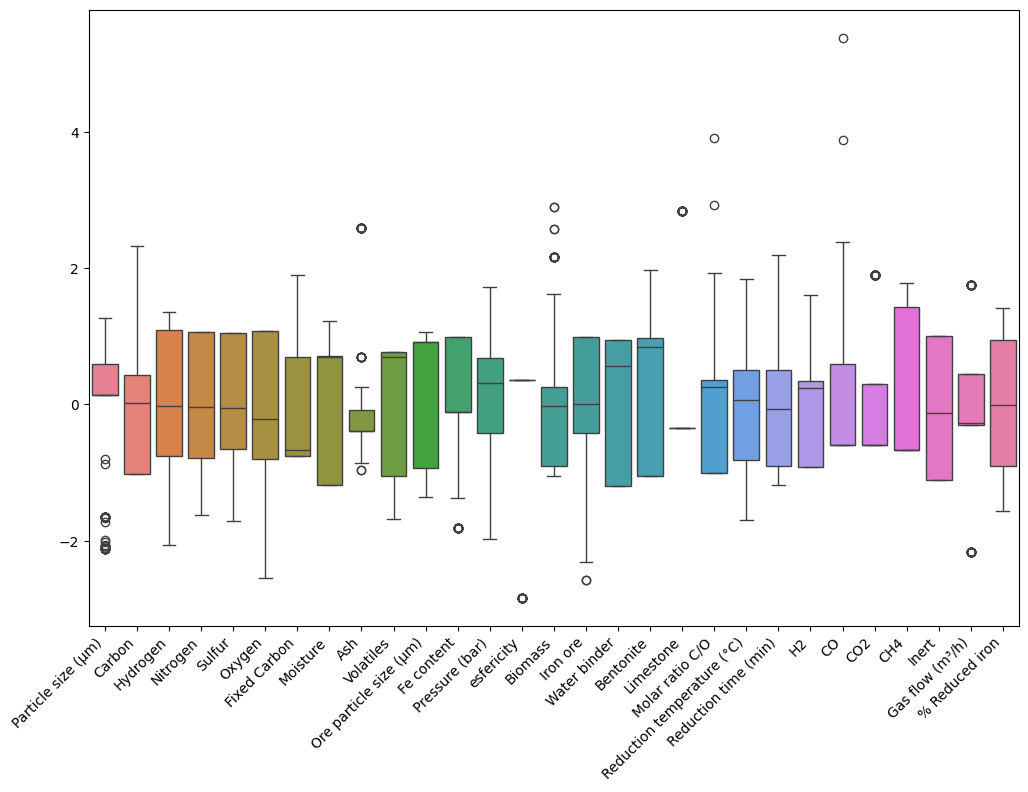

In [ ]:
# Boxplot for dataframe16
plt.figure(figsize=(12, 8))
sns.boxplot(data=df16)
plt.xticks(rotation=45, ha='right')
#plt.title('Boxplot of Variables in df16')
plt.show()

---


# **Models**


---

In [ ]:
# Obtaining a regression model for % Reduced iron
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

X = df16.drop(columns=['% Reduced iron']) # Independent variable
y = df16['% Reduced iron'] # Dependent variable

# Initializing the splitting of df
random = 42
kfold = KFold(n_splits=5, shuffle=True, random_state=random)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random)

---


# **AutoML**


---

In [ ]:
# Applying TPOT AutoML (Tree-Based Pipeline Optimization Tool)
!pip install tpot
!pip install --upgrade tpot

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.1/215.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.2 MB/s eta 0:00:00
  Created wheel for func-timeout: filename=func_timeout-4.3.5-py3-none-any.whl size=15077 sha256=5e743071578789f5c9bb3c0d5568a724916e9912da9dcd77af4c85164d1e0cf7
  Stored in directory: /root/.cache/pip/whee

In [ ]:
from tpot import TPOTRegressor
from sklearn.model_selection import train_test_split
import numpy as np

tpot_config = TPOTRegressor(
    generations=5,
    population_size=50,
    preprocessing=True,
    cv=5,
    scorers='r2',
    random_state=42,
    verbose=2,
    #n_jobs=-1,
    max_time_mins=60,
)

print("Starting TPOT search (Automated Machine Learning)...")

tpot_config.fit(X_train, y_train)

print("\nMelhor pipeline de AutoML encontrado:")
print(tpot_config.fitted_pipeline_)

# Performance metrics
from sklearn.metrics import mean_squared_error, r2_score

final_pipeline = tpot_config.fitted_pipeline_

y_pred_tpot = final_pipeline.predict(X_test)

final_r2 = r2_score(y_test, y_pred_tpot)
final_mse = mean_squared_error(y_test, y_pred_tpot)

print(f"R2 Score (via pipeline.predict): {final_r2:.4f}")
print(f"MSE (via pipeline.predict): {final_mse:.4f}")

/usr/local/lib/python3.12/dist-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:39621
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34545'


Starting TPOT search (Automated Machine Learning)...


INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:38995 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:38995
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:43452
INFO:distributed.scheduler:Receive client connection: Client-c6b331a8-eb11-11f0-a2d1-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:43464
Generation: 100%|██████████| 5/5 [19:46<00:00, 237.22s/it]
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1767713394.9905274') (0,)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:34545'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:43452; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:38995 name: 0 (stimulus_id='handle-worker-cleanup-1767713395.0032322')
ERROR:distributed.scheduler:Removing worker 


Melhor pipeline de AutoML encontrado:
Pipeline(steps=[('pipeline-1',
                 Pipeline(steps=[('impute_numeric', ColumnSimpleImputer())])),
                ('pipeline-2',
                 Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                                 ('rfe',
                                  RFE(estimator=ExtraTreesRegressor(bootstrap=np.False_,
                                                                    criterion=np.str_('absolute_error'),
                                                                    max_features=0.4878981885328,
                                                                    min_samples_leaf=2,
                                                                    min_samples_split=15,
                                                                    n_jobs=1,
                                                                    random_state=42),
                                      step=0...
                              

---


# **XGBoost Regressor**


---

In [ ]:
# XGBoost Regression
# Installying the library "XGBoost"
!pip install xgboost==3.0.5
!pip install --upgrade xgboost

In [ ]:
# XGBoost Regression
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

In [ ]:
# XGBoost Regressor
# Grid Search for Hyperparameters inside XGBoost Regressor
n_estimators_list = [10, 50, 100, 200]
max_depth_list = [None, 1, 2, 5, 10, 20]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5]
reg_alpha_list = [0, 0.001, 0.01, 0.1, 1]
reg_lambda_list = [0, 0.1, 1, 10, 20]

# List to store results for each combination (now storing mean R2)
results_list_xgb = []

print("Starting cross-validated manual hyperparameter search...")

# Loop through each combination of hyperparameters
for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
         for learning_rate in learning_rate_list:
             for reg_alpha in reg_alpha_list:
                 for reg_lambda in reg_lambda_list:
                     print(f"Testing n_estimators={n_estimators}, max_depth={max_depth}, learning_rate={learning_rate}, reg_alpha={reg_alpha}, reg_lambda={reg_lambda},...")

                     fold_r2_scores = []

                     try:
                         for fold, (train_index, test_index) in enumerate(kfold.split(X)):
                             X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
                             y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

                             # Creating a XGBoost Regressor model
                             model_xgb = xgb.XGBRegressor(objective='reg:squarederror',
                                      n_estimators=n_estimators,
                                      max_depth=max_depth,
                                      learning_rate=learning_rate,
                                      reg_alpha=reg_alpha,
                                      reg_lambda=reg_lambda,
                                      random_state=random)

                             model_xgb.fit(X_train_fold, y_train_fold)
                             y_pred_xgb_fold = model_xgb.predict(X_test_fold)
                             r2_fold = r2_score(y_test_fold, y_pred_xgb_fold)
                             fold_r2_scores.append(r2_fold)

                         # Calculating the metrics
                         if fold_r2_scores:
                              mean_r2 = np.mean(fold_r2_scores)
                              results_list_xgb.append({
                              'n_estimators': n_estimators,
                              'max_depth': str(max_depth),
                              'learning_rate': learning_rate,
                              'reg_alpha': reg_alpha,
                              'reg_lambda': reg_lambda,
                              'r2_score': mean_r2
                               })
                              print(f"  Average R2 Score across folds: {mean_r2:.3f}")
                         else:
                              results_list_xgb.append({
                                 'n_estimators': n_estimators,
                                 'max_depth': str(max_depth),
                                 'learning_rate': learning_rate,
                                 'reg_alpha': reg_alpha,
                                 'reg_lambda': reg_lambda,
                                 'r2_score': np.nan
                               })
                              print("  No valid R2 scores obtained across folds.")

                     except Exception as e:
                         print(f"  Error during K-fold evaluation for n_estimators={n_estimators}, max_depth={max_depth}, learning_rate={learning_rate}: {e}")
                         results_list_xgb.append({
                         'n_estimators': n_estimators,
                         'max_depth': str(max_depth),
                         'lerning_rate': learning_rate,
                         'reg_alpha': reg_alpha,
                         'reg_lambda': reg_lambda,
                         'r2_score': np.nan
                         })

print("Cross-validated manual search finished.")

# Dataframe of results
results_xgb = pd.DataFrame(results_list_xgb)
best_combination_xgb = results_xgb.loc[results_xgb['r2_score'].dropna().idxmax()]
print("\nBest combination found from cross-validated search (based on mean R2):")
print(best_combination_xgb)

In [ ]:
# Definitive model for XGBoost Regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Initialize lists to store metrics for each fold
mse_train_scores = []
mse_test_scores = []
rmse_train_scores = []
rmse_test_scores = []
mae_train_scores = []
mae_test_scores = []
r2_train_scores = []
r2_test_scores = []

# Iterate over the folds
for fold, (train_index, test_index) in enumerate(kfold.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Creating the model
    def_model_xgb = xgb.XGBRegressor(objective='reg:squarederror',
                                      n_estimators=200,
                                      max_depth=5,
                                      learning_rate=0.3,
                                      reg_alpha=0.0,
                                      reg_lambda=20,
                                      random_state=random)

    def_model_xgb.fit(X_train, y_train)
    y_pred_xgb_train = def_model_xgb.predict(X_train)
    y_pred_xgb = def_model_xgb.predict(X_test)

    # Calculating metrics (Train)
    mse_train = mean_squared_error(y_train, y_pred_xgb_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_pred_xgb_train)
    r2_train = r2_score(y_train, y_pred_xgb_train)

    # Calculating metrics (Test)
    mse_test = mean_squared_error(y_test, y_pred_xgb)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_xgb)
    r2_test = r2_score(y_test, y_pred_xgb)

    # Append metrics to lists
    mse_train_scores.append(mse_train)
    rmse_train_scores.append(rmse_train)
    mae_train_scores.append(mae_train)
    r2_train_scores.append(r2_train)

    mse_test_scores.append(mse_test)
    rmse_test_scores.append(rmse_test)
    mae_test_scores.append(mae_test)
    r2_test_scores.append(r2_test)

    print(f"Fold {fold + 1}:")
    print(f"  MSE (train e test): {mse_train:.4f} e {mse_test:.4f}")
    print(f"  RMSE (train e test): {rmse_train:.4f} e {rmse_test:.4f}")
    print(f"  MAE (train e test): {mae_train:.4f} e {mae_test:.4f}")
    print(f"  R-squared (train e test): {r2_train:.4f} e {r2_test:.4f}")

# Average metrics across all folds
avg_mse_train = np.mean(mse_train_scores)
avg_rmse_train = np.mean(rmse_train_scores)
avg_mae_train = np.mean(mae_train_scores)
avg_r2_train = np.mean(r2_train_scores)

avg_mse_test = np.mean(mse_test_scores)
avg_rmse_test = np.mean(rmse_test_scores)
avg_mae_test = np.mean(mae_test_scores)
avg_r2_test = np.mean(r2_test_scores)

print("\nAverage test metrics across all folds:")
print(f"  Average MSE (train e test): {avg_mse_train:.4f} e {avg_mse_test:.4f}")
print(f"  Average RMSE (train e test): {avg_rmse_train:.4f} e {avg_rmse_test:.4f}")
print(f"  Average MAE (train e test): {avg_mae_train:.4f} e {avg_mae_test:.4f}")
print(f"  Average R-squared (train e test): {avg_r2_train:.4f} e {avg_r2_test:.4f}")


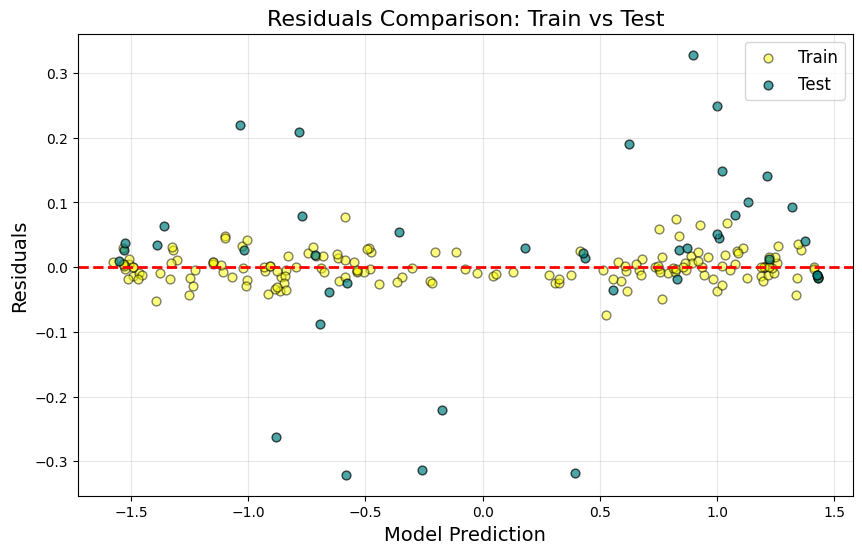

In [ ]:
# Parity plot comparison
import matplotlib.pyplot as plt

model_train = def_model_xgb.predict(X_train)
y_pred_train = model_train
model_test = def_model_xgb.predict(X_test)
y_pred_test = model_test

res_train = y_train - y_pred_train
res_test = y_test - y_pred_test

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_train, res_train, alpha=0.5, color='yellow', label='Train', edgecolors='k', s=40)
plt.scatter(y_pred_test, res_test, alpha=0.7, color='teal', label='Test', edgecolors='k', s=40)
plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.xlabel('Model Prediction', size=14)
plt.ylabel('Residuals', size=14)
plt.title('Residuals Comparison: Train vs Test', size=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.show()

In [ ]:
import joblib
from xgboost import XGBRegressor

joblib.dump(def_model_xgb, 'Total XGB.pkl')
print("\nTotal XGB model successfully saved.")

joblib.dump(scalers_por_coluna, 'scalers_por_coluna.pkl')
print("Scalers successfully saved.")


Total XGB model successfully saved.
Scalers successfully saved.


---


# **AdaBoost Regressor**


---

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor # Adaboost estimator
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Grid Search for Hyperparameters inside AdaBoost Regressor
n_estimators_list = [5, 10, 50, 100, 200]
max_depth_list = [None, 1, 2, 5, 10, 50]
learning_rate_list = [0.01, 0.1, 0.2, 0.5]

# List to store results for each combination
results_list_ada = []

print("Starting cross-validated manual hyperparameter search for AdaBoost...")

# Loop through each hyperparameter combinations
for n_estimators in n_estimators_list:
    for learning_rate in learning_rate_list:
        for max_depth in max_depth_list:

            print(f"Testing n_estimators={n_estimators}, learning_rate={learning_rate}, max_depth={max_depth}...")

            fold_r2_scores = []

            try:
                for fold, (train_index, test_index) in enumerate(kfold.split(X)):
                    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
                    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

                    # AdaBoost model
                    base_estimator = DecisionTreeRegressor(max_depth=max_depth, random_state=random)
                    model_ada = AdaBoostRegressor(
                        estimator=base_estimator,
                        n_estimators=n_estimators,
                        learning_rate=learning_rate,
                        random_state=random
                    )

                    model_ada.fit(X_train, y_train)
                    y_pred_ada = model_ada.predict(X_test)
                    r2_fold = r2_score(y_test, y_pred_ada)
                    fold_r2_scores.append(r2_fold)

                if fold_r2_scores:
                    mean_r2 = np.mean(fold_r2_scores)
                    results_list_ada.append({
                        'n_estimators': n_estimators,
                        'learning_rate': learning_rate,
                        'max_depth': str(max_depth),
                        'r2_score': mean_r2
                    })
                    print(f"  Average R2 Score across folds: {mean_r2:.3f}")
                else:
                    results_list_ada.append({
                        'n_estimators': n_estimators,
                        'learning_rate': learning_rate,
                        'max_depth': str(max_depth),
                        'r2_score': np.nan
                    })

            except Exception as e:
                print(f"  Error during K-fold evaluation: {e}")
                results_list_ada.append({
                     'n_estimators': n_estimators,
                     'learning_rate': learning_rate,
                     'max_depth': str(max_depth),
                     'r2_score': np.nan
                })


print("Cross-validated manual search for AdaBoost finished.")

# Results analysis
results_ada = pd.DataFrame(results_list_ada)
best_combination_ada = results_ada.loc[results_ada['r2_score'].dropna().idxmax()]
best_depth_for_heatmap = best_combination_ada['max_depth']
best_depth = results_ada[results_ada['max_depth'] == best_depth_for_heatmap]

# Heatmap for best combinations
pivot_table = best_depth.pivot(index='learning_rate', columns='n_estimators', values='r2_score')
pivot_table_filled = pivot_table.fillna(0.0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis", vmin=0.0, vmax=1.0)
plt.title('Average R-squared Score across K-Folds for Hyperparameter Combinations')
plt.xlabel('n_estimators')
plt.ylabel('learning_rate')
plt.show()

best_combination_ada = results_ada.loc[results_ada['r2_score'].dropna().idxmax()]
print("\nBest combination found from cross-validated search (based on mean R2):")
print(best_combination_ada)

In [ ]:
# Definitive model for AdaBoost Regression
# Initialize lists to store metrics for each fold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse_train_scores = []
mse_test_scores = []
rmse_train_scores = []
rmse_test_scores = []
mae_train_scores = []
mae_test_scores = []
r2_train_scores = []
r2_test_scores = []

# Iterate over the folds
for fold, (train_index, test_index) in enumerate(kfold.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Base estimator
    base_estimator = DecisionTreeRegressor(max_depth=None, random_state=random)

    # AdaBoost regressor model
    def_model_ada = AdaBoostRegressor(
                        estimator=base_estimator,
                        n_estimators=10,
                        learning_rate=0.2,
                        random_state=random
                    )

    # Training the model
    def_model_ada.fit(X_train, y_train)

    # Make predictions on the train and test sets
    y_pred_ada_train = def_model_ada.predict(X_train)
    y_pred_ada = def_model_ada.predict(X_test)

    # Calculating metrics for this fold (Train)
    mse_train = mean_squared_error(y_train, y_pred_ada_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_pred_ada_train)
    r2_train = r2_score(y_train, y_pred_ada_train)

    # Calculating metrics for this fold (Test)
    mse_test = mean_squared_error(y_test, y_pred_ada)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_ada)
    r2_test = r2_score(y_test, y_pred_ada)

    # Append metrics to lists
    mse_train_scores.append(mse_train)
    rmse_train_scores.append(rmse_train)
    mae_train_scores.append(mae_train)
    r2_train_scores.append(r2_train)

    mse_test_scores.append(mse_test)
    rmse_test_scores.append(rmse_test)
    mae_test_scores.append(mae_test)
    r2_test_scores.append(r2_test)

    print(f"Fold {fold + 1}:")
    print(f"  MSE (train e test): {mse_train:.4f} e {mse_test:.4f}")
    print(f"  RMSE (train e test): {rmse_train:.4f} e {rmse_test:.4f}")
    print(f"  MAE (train e test): {mae_train:.4f} e {mae_test:.4f}")
    print(f"  R-squared (train e test): {r2_train:.4f} e {r2_test:.4f}")


# Average metrics across all folds
avg_mse_train = np.mean(mse_train_scores)
avg_rmse_train = np.mean(rmse_train_scores)
avg_mae_train = np.mean(mae_train_scores)
avg_r2_train = np.mean(r2_train_scores)

avg_mse_test = np.mean(mse_test_scores)
avg_rmse_test = np.mean(rmse_test_scores)
avg_mae_test = np.mean(mae_test_scores)
avg_r2_test = np.mean(r2_test_scores)

print("\nAverage test metrics across all folds:")
print(f"  Average MSE (train e test): {avg_mse_train:.4f} e {avg_mse_test:.4f}")
print(f"  Average RMSE (train e test): {avg_rmse_train:.4f} e {avg_rmse_test:.4f}")
print(f"  Average MAE (train e test): {avg_mae_train:.4f} e {avg_mae_test:.4f}")
print(f"  Average R-squared (train e test): {avg_r2_train:.4f} e {avg_r2_test:.4f}")

In [ ]:
import joblib
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor # Adaboost estimator

joblib.dump(def_model_ada, 'Total ADA.pkl')
print("\nTotal ADA model successfully saved.")


Total ADA model successfully saved.


---


# **--> Shapley Analysis**


---

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
# XGB model
xgb_explainer_full = shap.Explainer(model=def_model_xgb.predict, masker=shap.sample(X_train))
xgb_shap_values_full = xgb_explainer_full(X_test, #check_additivity=False
                                          )
shap.summary_plot(xgb_shap_values_full, X_test)

In [ ]:
import numpy as np
import pandas as pd
import shap
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def perform_shap_rfe(X, y, kfold, model_params, random_state):

    initial_features = list(X.columns)
    current_features = initial_features.copy()
    results_rfe = []

    print("--- 1. Initial SHAP Values ---")

    # Training the SHAP model
    train_index, _ = next(kfold.split(X))
    X_train_full = X.iloc[train_index]
    y_train_full = y.iloc[train_index]
    def_model = xgb.XGBRegressor(**model_params, random_state=random_state)
    def_model.fit(X_train_full, y_train_full)

    # SHAP Explainer
    xgb_explainer = shap.Explainer(def_model.predict, X_train_full)
    xgb_shap_values = xgb_explainer(X_train_full)
    shap_importances = np.abs(xgb_shap_values.values).mean(axis=0)
    feature_ranking = pd.Series(shap_importances, index=X_train_full.columns).sort_values(ascending=False)
    ordered_features = feature_ranking.index.tolist()

    print(f"Initial SHAP Ranking: {ordered_features}")

    print("\n--- 2. Loop of Elimination and Reavaliation ---")

    # Feature removal for each round
    for i in range(len(initial_features)):

        features_to_keep = ordered_features[:len(initial_features) - i]

        if i > 0:
            removed_feature = ordered_features[len(initial_features) - i]
            print(f"\nRound {i}: Removing '{removed_feature}' ({len(features_to_keep)} features remaining)")
        else:
            print(f"\nRound {i}: All the {len(features_to_keep)} features")

        # --- K-Fold ---
        X_filtered = X[features_to_keep]

        mse_train_scores = []
        mae_train_scores = []
        r2_train_scores = []

        mse_test_scores = []
        mae_test_scores = []
        r2_test_scores = []

        for fold, (train_index, test_index) in enumerate(kfold.split(X_filtered)):
            X_train_fold, X_test_fold = X_filtered.iloc[train_index], X_filtered.iloc[test_index]
            y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

            model_rfe = xgb.XGBRegressor(**model_params, random_state=random)
            model_rfe.fit(X_train_fold, y_train_fold)

            y_pred_train = model_rfe.predict(X_train_fold)
            y_pred_test = model_rfe.predict(X_test_fold)
            mse_train_scores.append(mean_squared_error(y_train_fold, y_pred_train))
            mse_test_scores.append(mean_squared_error(y_test_fold, y_pred_test))
            mae_train_scores.append(mean_absolute_error(y_train_fold, y_pred_train))
            mae_test_scores.append(mean_absolute_error(y_test_fold, y_pred_test))
            r2_train_scores.append(r2_score(y_train_fold, y_pred_train))
            r2_test_scores.append(r2_score(y_test_fold, y_pred_test))

        # Performance metrics for each round
        avg_mse_train = np.mean(mse_train_scores)
        avg_rmse_train = np.sqrt(avg_mse_train)
        avg_mae_train = np.mean(mae_train_scores)
        avg_r2_train = np.mean(r2_train_scores)

        avg_mse_test = np.mean(mse_test_scores)
        avg_rmse_test = np.sqrt(avg_mse_test)
        avg_mae_test = np.mean(mae_test_scores)
        avg_r2_test = np.mean(r2_test_scores)

        results_rfe.append({
            'Num Features': len(features_to_keep),
            'Removed Features': initial_features if i == 0 else ordered_features[len(features_to_keep):],
            'Mean MSE Train': avg_mse_train,
            'Mean RMSE Train': avg_rmse_train,
            'Mean MAE Train': avg_mae_train,
            'Mean R2 Train': avg_r2_train,
            'Mean MSE Test': avg_mse_test,
            'Mean RMSE Test': avg_rmse_test,
            'Mean MAE Test': avg_mae_test,
            'Mean R2 Test': avg_r2_test
        })

        print(f"  Mean of the train metrics with {len(features_to_keep)} features: MSE = {avg_mse_train}, RMSE = {avg_rmse_train}, MAE = {avg_mae_train} e R² = {avg_r2_train:.4f}")
        print(f"  Mean of the test metrics with {len(features_to_keep)} features: MSE = {avg_mse_test}, RMSE = {avg_rmse_test}, MAE = {avg_mae_test} e R² = {avg_r2_test:.4f}")

    return pd.DataFrame(results_rfe)

# Simulation
# Total XGB hyperaparmeters
xgb_best_params = {
    #'objective': 'reg:squarederror',
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.3,
    'reg_alpha': 0.0,
    'reg_lambda': 20,
}

rfe_results_xgb = perform_shap_rfe(
    X=X,
    y=y,
    kfold=kfold,
    model_params=xgb_best_params,
    random_state=random
)

# Results
print("\n--- Results of the features elimination by SHAP values ---")
print(rfe_results_xgb)

best_r2_row = rfe_results_xgb.loc[rfe_results_xgb['Mean R2 Test'].idxmax()]
print("\Best R2 achieved:")
print(f"Maximum R2 for the Test: {best_r2_row['Mean R2 Test']:.4f}")
print(f"Equivalent R2 for the Train: {best_r2_row['Mean R2 Train']:.4f}")
print(f"With {best_r2_row['Num Features']} Features.")

In [ ]:
import matplotlib.pyplot as plt

def plot_rfe_results(df_results):
    plt.figure(figsize=(10, 6))
    plt.plot(df_results['Num Features'], df_results['Mean R2 Test'], marker='o', label='R² Test', color='blue')
    plt.plot(df_results['Num Features'], df_results['Mean MAE Test'], marker='s', label='MAE Test', color='orange', alpha=0.6)

    # Inverted axis
    plt.gca().invert_xaxis()

    #plt.title('Performance evolution through features removal', fontsize=14)
    plt.xlabel('Remaining features', fontsize=18)
    #plt.ylabel('Correlation coefficient (R²)', fontsize=12)
    plt.legend(prop={'size': 14})
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Running the function
plot_rfe_results(rfe_results_xgb)

In [ ]:
# Combined effect of the features
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_test_absolute = X_test.copy()

stats_temp = {
    'mean': df11['Reduction temperature (°C)'].mean(),
    'std': df11['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df11['Reduction time (min)'].mean(),
    'std': df11['Reduction time (min)'].std(ddof=0)
}

stats_H2 = {
    'mean': df11['H2'].mean(),
    'std': df11['H2'].std(ddof=0)
}

stats_CO = {
    'mean': df11['CO'].mean(),
    'std': df11['CO'].std(ddof=0)
}

stats_fixed_carbon = {
    'mean': df11['Fixed Carbon'].mean(),
    'std': df11['Fixed Carbon'].std(ddof=0)
}

X_test_absolute['Reduction temperature (°C)'] = (X_test['Reduction temperature (°C)'] * stats_temp['std']) + stats_temp['mean']
X_test_absolute['Reduction time (min)'] = (X_test['Reduction time (min)'] * stats_time['std']) + stats_time['mean']
X_test_absolute['H2'] = (X_test['H2'] * stats_H2['std']) + stats_H2['mean']
X_test_absolute['CO'] = (X_test['CO'] * stats_CO['std']) + stats_CO['mean']
X_test_absolute['Fixed Carbon'] = (X_test['Fixed Carbon'] * stats_fixed_carbon['std']) + stats_fixed_carbon['mean']

# Features pair
feature_names_all = [
    'Reduction temperature (°C)',
    'H2',
]

main_feature = 'Reduction temperature (°C)'
secondary_feature = 'H2'
feature_names_plot = X_test.columns.tolist()
idx_principal = X_test.columns.get_loc(main_feature)

# Extrating the Shap values
shap_values_plot = xgb_shap_values_full.values

# Plotting the graph
shap.dependence_plot(
    ind=idx_principal,
    shap_values=shap_values_plot,
    features=X_test_absolute,
    feature_names=feature_names_plot,
    interaction_index=secondary_feature,
    display_features=X_test_absolute
)

In [ ]:
# ADA model
ada_explainer_full = shap.Explainer(model=def_model_ada.predict, masker=shap.sample(X_train))
ada_shap_values_full = ada_explainer_full(X_test,
                                          #check_additivity=False
                                          )
shap.summary_plot(ada_shap_values_full, X_test)

In [ ]:
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor # Adaboost estimator
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def perform_shap_rfe(X, y, kfold, model_params, random_state):

    initial_features = list(X.columns)
    current_features = initial_features.copy()
    results_rfe = []

    train_index, _ = next(kfold.split(X))
    X_train_full = X.iloc[train_index]
    y_train_full = y.iloc[train_index]

    def_model = AdaBoostRegressor(**model_params, random_state=random_state)
    def_model.fit(X_train_full, y_train_full)

    ada_explainer = shap.Explainer(def_model.predict, X_train_full)
    ada_shap_values = ada_explainer(X_train_full)

    shap_importances = np.abs(ada_shap_values.values).mean(axis=0)

    feature_ranking = pd.Series(shap_importances, index=X_train_full.columns).sort_values(ascending=False)

    ordered_features = feature_ranking.index.tolist()

    print(f"Initial Ranking SHAP: {ordered_features}")

    print("\n Elimination and Reavaliation Loop")

    for i in range(len(initial_features)):

        features_to_keep = ordered_features[:len(initial_features) - i]

        if i > 0:
            removed_feature = ordered_features[len(initial_features) - i]
            print(f"\nRound {i}: Removing '{removed_feature}' ({len(features_to_keep)} features remaining)")
        else:
            print(f"\nRound {i}: All the {len(features_to_keep)} features")

        X_filtered = X[features_to_keep]

        mse_train_scores = []
        mae_train_scores = []
        r2_train_scores = []

        mse_test_scores = []
        mae_test_scores = []
        r2_test_scores = []

        for fold, (train_index, test_index) in enumerate(kfold.split(X_filtered)):

            X_train_fold, X_test_fold = X_filtered.iloc[train_index], X_filtered.iloc[test_index]
            y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

            model_rfe = AdaBoostRegressor(**model_params, random_state=random)
            model_rfe.fit(X_train_fold, y_train_fold)

            y_pred_train = model_rfe.predict(X_train_fold)
            y_pred_test = model_rfe.predict(X_test_fold)
            mse_train_scores.append(mean_squared_error(y_train_fold, y_pred_train))
            mse_test_scores.append(mean_squared_error(y_test_fold, y_pred_test))
            mae_train_scores.append(mean_absolute_error(y_train_fold, y_pred_train))
            mae_test_scores.append(mean_absolute_error(y_test_fold, y_pred_test))
            r2_train_scores.append(r2_score(y_train_fold, y_pred_train))
            r2_test_scores.append(r2_score(y_test_fold, y_pred_test))

        avg_mse_train = np.mean(mse_train_scores)
        avg_rmse_train = np.sqrt(avg_mse_train)
        avg_mae_train = np.mean(mae_train_scores)
        avg_r2_train = np.mean(r2_train_scores)

        avg_mse_test = np.mean(mse_test_scores)
        avg_rmse_test = np.sqrt(avg_mse_test)
        avg_mae_test = np.mean(mae_test_scores)
        avg_r2_test = np.mean(r2_test_scores)

        results_rfe.append({
            'Num Features': len(features_to_keep),
            'Removed Features': initial_features if i == 0 else ordered_features[len(features_to_keep):],
            'Mean MSE Train': avg_mse_train,
            'Mean RMSE Train': avg_rmse_train,
            'Mean MAE Train': avg_mae_train,
            'Mean R2 Train': avg_r2_train,
            'Mean MSE Test': avg_mse_test,
            'Mean RMSE Test': avg_rmse_test,
            'Mean MAE Test': avg_mae_test,
            'Mean R2 Test': avg_r2_test
        })

        print(f"  Mean train metrics {len(features_to_keep)} features: MSE = {avg_mse_train}, RMSE = {avg_rmse_train}, MAE = {avg_mae_train} e R² = {avg_r2_train:.4f}")
        print(f"  Mean test metrics {len(features_to_keep)} features: MSE = {avg_mse_test}, RMSE = {avg_rmse_test}, MAE = {avg_mae_test} e R² = {avg_r2_test:.4f}")

    return pd.DataFrame(results_rfe)

ada_best_params = {
    'estimator': DecisionTreeRegressor(max_depth=10, random_state=random),
    'n_estimators': 100,
    'learning_rate': 0.1
}

rfe_results_ada = perform_shap_rfe(
    X=X,
    y=y,
    kfold=kfold,
    model_params=ada_best_params,
    random_state=random
)

print("\n--- SHAP Elimination Features Results ---")
print(rfe_results_ada)

best_r2_row = rfe_results_ada.loc[rfe_results_ada['Mean R2 Test'].idxmax()]
print("\nBest R2 Achieved:")
print(f"Maximum Mean R2 Test: {best_r2_row['Mean R2 Test']:.4f}")
print(f"Equivalent R2 Train: {best_r2_row['Mean R2 Train']:.4f}")
print(f"With {best_r2_row['Num Features']} Features.")

In [ ]:
# Running the function of metrics
plot_rfe_results(rfe_results_ada)

In [ ]:
# Combined effect of the features
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor # Adaboost estimator
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_test_absolute = X_test.copy()

stats_temp = {
    'mean': df11['Reduction temperature (°C)'].mean(),
    'std': df11['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df11['Reduction time (min)'].mean(),
    'std': df11['Reduction time (min)'].std(ddof=0)
}

stats_H2 = {
    'mean': df11['H2'].mean(),
    'std': df11['H2'].std(ddof=0)
}

stats_CO = {
    'mean': df11['CO'].mean(),
    'std': df11['CO'].std(ddof=0)
}

stats_fixed_carbon = {
    'mean': df11['Fixed Carbon'].mean(),
    'std': df11['Fixed Carbon'].std(ddof=0)
}

X_test_absolute['Reduction temperature (°C)'] = (X_test['Reduction temperature (°C)'] * stats_temp['std']) + stats_temp['mean']
X_test_absolute['Reduction time (min)'] = (X_test['Reduction time (min)'] * stats_time['std']) + stats_time['mean']
X_test_absolute['H2'] = (X_test['H2'] * stats_H2['std']) + stats_H2['mean']
X_test_absolute['CO'] = (X_test['CO'] * stats_CO['std']) + stats_CO['mean']
X_test_absolute['Fixed Carbon'] = (X_test['Fixed Carbon'] * stats_fixed_carbon['std']) + stats_fixed_carbon['mean']

# Features pair
feature_names_all = [
    'Reduction temperature (°C)',
    'H2',
]

main_feature = 'Reduction temperature (°C)'
secondary_feature = 'H2'
feature_names_plot = X_test.columns.tolist()
idx_principal = X_test.columns.get_loc(main_feature)

# Extrating the Shap values
shap_values_plot = ada_shap_values_full.values

# Plotting the graph
shap.dependence_plot(
    ind=idx_principal,
    shap_values=shap_values_plot,
    features=X_test_absolute,
    feature_names=feature_names_plot,
    interaction_index=secondary_feature,
    display_features=X_test_absolute
)

In [ ]:
# Shap XGB model
df16_SHAP_XGB = df16.copy()
y_shap = df16_SHAP_XGB['% Reduced iron']
X_shap = df16_SHAP_XGB.drop(columns=['% Reduced iron', 'Nitrogen', 'Biomass', 'Fixed Carbon',
                           'Sulfur', 'Oxygen', 'Moisture', 'Ash', 'Volatiles', 'Ore particle size (µm)',
                           'Fe content', 'Pressure (bar)', 'esfericity', 'Iron ore', 'Bentonite', 'Limestone',
                           'Molar ratio C/O', 'CO', 'CO2', 'CH4', 'Inert', 'Gas flow (m³/h)'])

random = 42
kfold = KFold(n_splits=5, shuffle=True, random_state=random)
X_shap_train, X_shap_test, y_shap_train, y_shap_test = train_test_split(X_shap, y_shap, test_size=0.2, random_state=random)

shap_xgb_explainer_full = shap.Explainer(model=def_model_shap_xgb.predict, masker=shap.sample(X_shap_train))
shap_xgb_shap_values_full = shap_xgb_explainer_full(X_shap_test, #check_additivity=False
                                          )
shap.summary_plot(shap_xgb_shap_values_full, X_shap_test)

In [ ]:
# Combined effect of the features
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_shap_test_absolute = X_shap_test.copy()

stats_temp = {
    'mean': df11['Reduction temperature (°C)'].mean(),
    'std': df11['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df11['Reduction time (min)'].mean(),
    'std': df11['Reduction time (min)'].std(ddof=0)
}

stats_H2 = {
    'mean': df11['H2'].mean(),
    'std': df11['H2'].std(ddof=0)
}

X_shap_test_absolute['Reduction temperature (°C)'] = (X_shap_test['Reduction temperature (°C)'] * stats_temp['std']) + stats_temp['mean']
X_shap_test_absolute['Reduction time (min)'] = (X_shap_test['Reduction time (min)'] * stats_time['std']) + stats_time['mean']
X_shap_test_absolute['H2'] = (X_shap_test['H2'] * stats_H2['std']) + stats_H2['mean']

# Features pair
feature_names_all = [
    'Reduction temperature (°C)',
    'H2',
]

main_feature = 'Reduction temperature (°C)'
secondary_feature = 'H2'
feature_names_plot = X_shap_test.columns.tolist()
idx_principal = X_shap_test.columns.get_loc(main_feature)

# Extrating the Shap values
shap_values_plot = shap_xgb_shap_values_full.values

# Plotting the graph
shap.dependence_plot(
    ind=idx_principal,
    shap_values=shap_values_plot,
    features=X_shap_test_absolute,
    feature_names=feature_names_plot,
    interaction_index=secondary_feature,
    display_features=X_shap_test_absolute
)

In [ ]:
# Shap ADA model
df16_SHAP_ADA = df16.copy()
y_shap = df16_SHAP_ADA['% Reduced iron']
X_shap = df16_SHAP_ADA.drop(columns=['% Reduced iron', 'Nitrogen', 'Oxygen',
                           'Fixed Carbon', 'Ash', 'Volatiles', 'Biomass', 'Molar ratio C/O',
                           'Ore particle size (µm)', 'Fe content', 'esfericity', 'Iron ore', 'Bentonite', 'Limestone',
                            'CO', 'CO2', 'CH4', 'Inert', 'Gas flow (m³/h)'])

random = 50
kfold = KFold(n_splits=5, shuffle=True, random_state=random)
X_shap_train, X_shap_test, y_shap_train, y_shap_test = train_test_split(X_shap, y_shap, test_size=0.2, random_state=random)

shap_ada_explainer_full = shap.Explainer(model=def_model_shap_ada.predict, masker=shap.sample(X_shap_train))
shap_ada_shap_values_full = shap_ada_explainer_full(X_shap_test, #check_additivity=False
                                          )
shap.summary_plot(shap_ada_shap_values_full, X_shap_test)

In [ ]:
# Combined effect of the features
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor # Adaboost estimator
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_shap_test_absolute = X_shap_test.copy()

stats_temp = {
    'mean': df11['Reduction temperature (°C)'].mean(),
    'std': df11['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df11['Reduction time (min)'].mean(),
    'std': df11['Reduction time (min)'].std(ddof=0)
}

stats_H2 = {
    'mean': df11['H2'].mean(),
    'std': df11['H2'].std(ddof=0)
}

X_shap_test_absolute['Reduction temperature (°C)'] = (X_shap_test['Reduction temperature (°C)'] * stats_temp['std']) + stats_temp['mean']
X_shap_test_absolute['Reduction time (min)'] = (X_shap_test['Reduction time (min)'] * stats_time['std']) + stats_time['mean']
X_shap_test_absolute['H2'] = (X_shap_test['H2'] * stats_H2['std']) + stats_H2['mean']

# Features pair
feature_names_all = [
    'Reduction temperature (°C)',
    'H2',
]

main_feature = 'Reduction temperature (°C)'
secondary_feature = 'H2'
feature_names_plot = X_shap_test.columns.tolist()
idx_principal = X_shap_test.columns.get_loc(main_feature)

# Extrating the Shap values
shap_values_plot = shap_ada_shap_values_full.values

# Plotting the graph
shap.dependence_plot(
    ind=idx_principal,
    shap_values=shap_values_plot,
    features=X_shap_test_absolute,
    feature_names=feature_names_plot,
    interaction_index=secondary_feature,
    display_features=X_shap_test_absolute
)

# **--> Previsões**

In [ ]:
# Identifying values out of the training range
import pandas as pd
import numpy as np

absolute_values = {
    'Particle size (µm)': 200,
    'Carbon': 0.4867, # Islam et al. (2010)
    'Hydrogen': 0.067, # Islam et al. (2010)
    'Nitrogen': 0.0045, # Islam et al. (2010)
    'Sulfur': 0.0008, # Islam et al. (2010)
    'Oxygen': 0.4410, # Islam et al. (2010)
    'Fixed Carbon': 0.201, # Islam et al. (2010)
    'Moisture': 0.10,
    'Ash': 0.0414, # Islam et al. (2010)
    'Volatiles': 0.7585, # Islam et al. (2010)
    'Ore particle size (µm)': 200,
    'Fe content': 0.65,
    'Pressure (bar)': 25,
    'esfericity': 0.85714,
    'Biomass': 0.4328,
    'Iron ore': 0.5672,
    'Water binder': 0,
    'Bentonite': 0,
    'Limestone': 0,
    'Molar ratio C/O': 1.25,
    'Reduction temperature (°C)': 1000,
    'Reduction time (min)': 15,
    'H2': 0.456,
    'CO': 0.362,
    'CO2': 0.123,
    'CH4': 0.059,
    'Inert': 0,
    'Gas flow (m³/h)': 0.03
}

for feature, value in absolute_values.items():
    original_min = df11[feature].min()
    original_max = df11[feature].max()

    is_in_range = (value >= original_min) and (value <= original_max)

    if not is_in_range:
        print(f"Out of range for {feature}: {value}. The range is: [{original_min:.4f}, {original_max:.4f}]")

In [ ]:
# Obtaining the padronized values
# Get the mean and std values from the original data

original_mean_Particle_size = df11['Particle size (µm)'].mean()
original_std_Particle_size = df11['Particle size (µm)'].std()

original_mean_Carbon = df11['Carbon'].mean()
original_std_Carbon = df11['Carbon'].std()

original_mean_Hydrogen = df11['Hydrogen'].mean()
original_std_Hydrogen = df11['Hydrogen'].std()

original_mean_Nitrogen = df11['Nitrogen'].mean()
original_std_Nitrogen = df11['Nitrogen'].std()

original_mean_Sulfur = df11['Sulfur'].mean()
original_std_Sulfur = df11['Sulfur'].std()

original_mean_Oxygen = df11['Oxygen'].mean()
original_std_Oxygen = df11['Oxygen'].std()

original_mean_Fixed_Carbon = df11['Fixed Carbon'].mean()
original_std_Fixed_Carbon = df11['Fixed Carbon'].std()

original_mean_Moisture = df11['Moisture'].mean()
original_std_Moisture = df11['Moisture'].std()

original_mean_Ash = df11['Ash'].mean()
original_std_Ash = df11['Ash'].std()

original_mean_Volatiles = df11['Volatiles'].mean()
original_std_Volatiles = df11['Volatiles'].std()

original_mean_Ore_particle_size = df11['Ore particle size (µm)'].mean()
original_std_Ore_particle_size = df11['Ore particle size (µm)'].std()

original_mean_Fe_content = df11['Fe content'].mean()
original_std_Fe_content = df11['Fe content'].std()

original_mean_Pressure = df11['Pressure (bar)'].mean()
original_std_Pressure = df11['Pressure (bar)'].std()

original_mean_esfericity = df11['esfericity'].mean()
original_std_esfericity = df11['esfericity'].std()

original_mean_Biomass = df11['Biomass'].mean()
original_std_Biomass = df11['Biomass'].std()

original_mean_iron_ore = df11['Iron ore'].mean()
original_std_iron_ore = df11['Iron ore'].std()

original_mean_water_binder = df11['Water binder'].mean()
original_std_water_binder = df11['Water binder'].std()

original_mean_Bentonite = df11['Bentonite'].mean()
original_std_Bentonite = df11['Bentonite'].std()

original_mean_Limestone = df11['Limestone'].mean()
original_std_Limestone = df11['Limestone'].std()

original_mean_Molar_ratio_CO = df11['Molar ratio C/O'].mean()
original_std_Molar_ratio_CO = df11['Molar ratio C/O'].std()

original_mean_reduction_temperature = df11['Reduction temperature (°C)'].mean()
original_std_reduction_temperature = df11['Reduction temperature (°C)'].std()

original_mean_reduction_time = df11['Reduction time (min)'].mean()
original_std_reduction_time = df11['Reduction time (min)'].std()

original_mean_H2 = df11['H2'].mean()
original_std_H2 = df11['H2'].std()

original_mean_CO = df11['CO'].mean()
original_std_CO = df11['CO'].std()

original_mean_CO2 = df11['CO2'].mean()
original_std_CO2 = df11['CO2'].std()

original_mean_CH4 = df11['CH4'].mean()
original_std_CH4 = df11['CH4'].std()

original_mean_Inert = df11['Inert'].mean()
original_std_Inert = df11['Inert'].std()

original_mean_Gas_flow = df11['Gas flow (m³/h)'].mean()
original_std_Gas_flow = df11['Gas flow (m³/h)'].std()

original_mean_iron_reduction = df11['% Reduced iron'].mean()
original_std_iron_reduction = df11['% Reduced iron'].std()

# Absolute values
Particle_size = 200
Carbon = 0.4867 # Islam et al. (2010)
Hydrogen = 0.067 # Islam et al. (2010)
Nitrogen = 0.0045 # Islam et al. (2010)
Sulfur = 0.0008 # Islam et al. (2010)
Oxygen = 0.4410 # Islam et al. (2010)
Fixed_Carbon = 0.201 # Islam et al. (2010)
Moisture = 0.10
Ash = 0.0414 # Islam et al. (2010)
Volatiles = 0.7585 # Islam et al. (2010)
Ore_particle_size = 200
Fe_content = 0.65
Pressure = 25
esfericity = 0.85714
Biomass = 0.4328
Iron_ore = 0.5672
Water_binder = 0
Bentonite = 0
Limestone = 0
Molar_ratio_CO = 1.25
Reduction_temperature = 1000
Reduction_time = 15
H2 = 0.456 # Guo et al. (2017)
CO = 0.362 # Guo et al. (2017)
CO2 = 0.123 # Guo et al. (2017)
CH4 = 0.059 # Guo et al. (2017)
Inert = 0 # Guo et al. (2017)
Gas_flow = 0.03

# Calculating the padronized values
Particle_size_standardized = (Particle_size - original_mean_Particle_size) / original_std_Particle_size
Carbon_standardized = (Carbon - original_mean_Carbon) / original_std_Carbon
Hydrogen_standardized = (Hydrogen - original_mean_Hydrogen) / original_std_Hydrogen
Nitrogen_standardized = (Nitrogen - original_mean_Nitrogen) / original_std_Nitrogen
Sulfur_standardized = (Sulfur - original_mean_Sulfur) / original_std_Sulfur
Oxygen_standardized = (Oxygen - original_mean_Oxygen) / original_std_Oxygen
Fixed_Carbon_standardized = (Fixed_Carbon - original_mean_Fixed_Carbon) / original_std_Fixed_Carbon
Moisture_standardized = (Moisture - original_mean_Moisture) / original_std_Moisture
Ash_standardized = (Ash - original_mean_Ash) / original_std_Ash
Volatiles_standardized = (Volatiles - original_mean_Volatiles) / original_std_Volatiles
Ore_particle_size_standardized = (Ore_particle_size - original_mean_Ore_particle_size) / original_std_Ore_particle_size
Fe_content_standardized = (Fe_content - original_mean_Fe_content) / original_std_Fe_content
Pressure_standardized = (Pressure - original_mean_Pressure) / original_std_Pressure
esfericity_standardized = (esfericity - original_mean_esfericity) / original_std_esfericity
Biomass_standardized = (Biomass - original_mean_Biomass) / original_std_Biomass
Iron_ore_standardized = (Iron_ore - original_mean_iron_ore) / original_std_iron_ore
Water_binder_standardized = (Water_binder - original_mean_water_binder) / original_std_water_binder
Bentonite_standardized = (Bentonite - original_mean_Bentonite) / original_std_Bentonite
Limestone_standardized = (Limestone - original_mean_Limestone) / original_std_Limestone
Molar_ratio_CO_standardized = (Molar_ratio_CO - original_mean_Molar_ratio_CO) / original_std_Molar_ratio_CO
Reduction_temperature_standardized = (Reduction_temperature - original_mean_reduction_temperature) / original_std_reduction_temperature
Reduction_time_standardized = (Reduction_time - original_mean_reduction_time) / original_std_reduction_time
H2_standardized = (H2 - original_mean_H2) / original_std_H2
CO_standardized = (CO - original_mean_CO) / original_std_CO
CO2_standardized = (CO2 - original_mean_CO2) / original_std_CO2
CH4_standardized = (CH4 - original_mean_CH4) / original_std_CH4
Inert_standardized = (Inert - original_mean_Inert) / original_std_Inert
Gas_flow_standardized = (Gas_flow - original_mean_Gas_flow) / original_std_Gas_flow

print(f"Particle_size_standardized: {Particle_size_standardized:.4f}")
print(f"Carbon_standardized: {Carbon_standardized:.4f}")
print(f"Hydrogen_standardized: {Hydrogen_standardized:.4f}")
print(f"Nitrogen_standardized: {Nitrogen_standardized:.4f}")
print(f"Sulfur_standardized: {Sulfur_standardized:.4f}")
print(f"Oxygen_standardized: {Oxygen_standardized:.4f}")
print(f"Fixed_Carbon_standardized: {Fixed_Carbon_standardized:.4f}")
print(f"Moisture_standardized: {Moisture_standardized:.4f}")
print(f"Ash_standardized: {Ash_standardized:.4f}")
print(f"Volatiles_standardized: {Volatiles_standardized:.4f}")
print(f"Ore_particle_size_standardized: {Ore_particle_size_standardized:.4f}")
print(f"Fe_content_standardized: {Fe_content_standardized:.4f}")
print(f"Pressure_standardized: {Pressure_standardized:.4f}")
print(f"esfericity_standardized: {esfericity_standardized:.4f}")
print(f"Biomass_standardized: {Biomass_standardized:.4f}")
print(f"Iron_ore_standardized: {Iron_ore_standardized:.4f}")
print(f"Water_binder_standardized: {Water_binder_standardized:.4f}")
print(f"Bentonite_standardized: {Bentonite_standardized:.4f}")
print(f"Limestone_standardized: {Limestone_standardized:.4f}")
print(f"Molar_ratio_C_O_standardized: {Molar_ratio_CO_standardized:.4f}")
print(f"Reduction_temperature_standardized: {Reduction_temperature_standardized:.4f}")
print(f"Reduction_time_standardized: {Reduction_time_standardized:.4f}")
print(f"H2_standardized: {H2_standardized:.4f}")
print(f"CO_standardized: {CO_standardized:.4f}")
print(f"CO2_standardized: {CO2_standardized:.4f}")
print(f"CH4_standardized: {CH4_standardized:.4f}")
print(f"Inert_standardized: {Inert_standardized:.4f}")
print(f"Gas_flow_standardized: {Gas_flow_standardized:.4f}")

In [ ]:
# Making predictions of confidence interval of Total XGBoost Regressor Model
from xgboost import XGBRegressor
from sklearn.utils import resample
from sklearn.base import clone

input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

# Making the prediction of the model
predicted_reduction_xgb = def_model_xgb.predict(input_data)[0]

# Bootstrap resampling technique
num_bootstrap_samples = 1000
bootstrap_predictions_xgb = []

for _ in range(num_bootstrap_samples):
    # Creating a bootstrap sample
    X_bootstrap, y_bootstrap = resample(X_train, y_train)

    # Training models on the bootstrap sample
    bootstrap_model_xgb = clone(def_model_xgb)
    bootstrap_model_xgb.fit(X_bootstrap, y_bootstrap)

    # Making predictions on your input data
    bootstrap_pred_input_xgb = bootstrap_model_xgb.predict(input_data)[0]

    # Storing the predictions
    bootstrap_predictions_xgb.append(bootstrap_pred_input_xgb)

# Calculating lower and upper bounds of prediction intervals (95% CI)
bootstrap_predictions_xgb = np.array(bootstrap_predictions_xgb)
predicted_reduction_xgb_absolute = predicted_reduction_xgb * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
lower_bound_xgb = np.percentile(bootstrap_predictions_xgb, 2.5, axis=0)
lower_bound_xgb_absolute = lower_bound_xgb * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
upper_bound_xgb = np.percentile(bootstrap_predictions_xgb, 97.5, axis=0)
upper_bound_xgb_absolute = upper_bound_xgb * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

# Print the predictions with confidence intervals
print(f"Actual: {y_test.iloc[0]}, Predicted_XGB: {predicted_reduction_xgb}, 95% CI: [{lower_bound_xgb}, {upper_bound_xgb}]")
print(f"Actual: {y_test.iloc[0]}, Predicted_XGB_absolute: {predicted_reduction_xgb_absolute}, 95% CI: [{lower_bound_xgb_absolute}, {upper_bound_xgb_absolute}]")

In [ ]:
# Conformal prediction for Confidence Interval
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_calib_pred_std = def_model_xgb.predict(X_test)
y_calib_pred_abs = y_calib_pred_std * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
y_calib_real_abs = y_test * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

residuos_calib = np.abs(y_calib_real_abs - y_calib_pred_abs)

# Confidence level
alpha = 0.05
q_hat = np.percentile(residuos_calib, 100 * (1 - alpha))
q_hat_100 = 100*q_hat
#print(f"{q_hat:.4f}")

# Histogram plot
plt.figure(figsize=(10, 6))
sns.histplot(residuos_calib, kde=True#, color='blue'
             )
plt.axvline(q_hat, color='red', linestyle='--', label=f'CI = {(1-alpha)*100} %')

plt.xlabel('Absolute Error', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.legend()
plt.show()

# Making the prediction of the model
input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

predicted_reduction_xgb = def_model_xgb.predict(input_data)[0]
predicted_reduction_xgb_absolute = predicted_reduction_xgb * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

print(f"Predicted_XGB_absolute: {predicted_reduction_xgb_absolute:.4f} +/- {q_hat:.4f}")

In [ ]:
# Make prediction using the Shapley XGB regressor

df16_SHAP_XGB = df16.copy()
y_shap = df16_SHAP_XGB['% Reduced iron']
X_shap = df16_SHAP_XGB.drop(columns=['% Reduced iron', 'Nitrogen', 'Biomass', 'Fixed Carbon',
                           'Sulfur', 'Oxygen', 'Moisture', 'Ash', 'Volatiles', 'Ore particle size (µm)',
                           'Fe content', 'Pressure (bar)', 'esfericity', 'Iron ore', 'Bentonite', 'Limestone',
                           'Molar ratio C/O', 'CO', 'CO2', 'CH4', 'Inert', 'Gas flow (m³/h)'])

random = 50
kfold = KFold(n_splits=5, shuffle=True, random_state=random)
X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(X_shap, y_shap, test_size=0.2, random_state=random)

# Definitive model for SHAP XGBoost Regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Initialize lists to store metrics for each fold
mse_train_scores = []
mse_test_scores = []
rmse_train_scores = []
rmse_test_scores = []
mae_train_scores = []
mae_test_scores = []
r2_train_scores = []
r2_test_scores = []

# Iterate over the folds using X_shap_filtered
for fold, (train_index, test_index) in enumerate(kfold.split(X_shap)):
    X_train_fold_shap, X_test_fold_shap = X_shap.iloc[train_index], X_shap.iloc[test_index]
    y_train_fold_shap, y_test_fold_shap = y_shap.iloc[train_index], y_shap.iloc[test_index]

    # Creating the model
    def_model_shap_xgb = xgb.XGBRegressor(objective='reg:squarederror',
                                      n_estimators=,
                                      max_depth=,
                                      learning_rate=,
                                      reg_alpha=,
                                      reg_lambda=,
                                      random_state=)

    # Training and testing the model
    def_model_shap_xgb.fit(X_train_fold_shap, y_train_fold_shap)
    y_pred_shap_xgb_train = def_model_shap_xgb.predict(X_train_fold_shap)
    y_pred_shap_xgb_test_fold = def_model_shap_xgb.predict(X_test_fold_shap)

    # Train metrics
    mse_train = mean_squared_error(y_train_fold_shap, y_pred_shap_xgb_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train_fold_shap, y_pred_shap_xgb_train)
    r2_train = r2_score(y_train_fold_shap, y_pred_shap_xgb_train)

    # Test metrics
    mse_test = mean_squared_error(y_test_fold_shap, y_pred_shap_xgb_test_fold)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test_fold_shap, y_pred_shap_xgb_test_fold)
    r2_test = r2_score(y_test_fold_shap, y_pred_shap_xgb_test_fold)

    mse_train_scores.append(mse_train)
    rmse_train_scores.append(rmse_train)
    mae_train_scores.append(mae_train)
    r2_train_scores.append(r2_train)

    mse_test_scores.append(mse_test)
    rmse_test_scores.append(rmse_test)
    mae_test_scores.append(mae_test)
    r2_test_scores.append(r2_test)

    print(f"Fold {fold + 1}:")
    print(f"  MSE (train e test): {mse_train:.4f} e {mse_test:.4f}")
    print(f"  RMSE (train e test): {rmse_train:.4f} e {rmse_test:.4f}")
    print(f"  MAE (train e test): {mae_train:.4f} e {mae_test:.4f}")
    print(f"  R-squared (train e test): {r2_train:.4f} e {r2_test:.4f}")


# Average metrics across all folds
avg_mse_train = np.mean(mse_train_scores)
avg_rmse_train = np.mean(rmse_train_scores)
avg_mae_train = np.mean(mae_train_scores)
avg_r2_train = np.mean(r2_train_scores)

avg_mse_test = np.mean(mse_test_scores)
avg_rmse_test = np.mean(rmse_test_scores)
avg_mae_test = np.mean(mae_test_scores)
avg_r2_test = np.mean(r2_test_scores)

print("\nAverage test metrics across all folds:")
print(f"  Average MSE (train e test): {avg_mse_train:.4f} e {avg_mse_test:.4f}")
print(f"  Average RMSE (train e test): {avg_rmse_train:.4f} e {avg_rmse_test:.4f}")
print(f"  Average MAE (train e test): {avg_mae_train:.4f} e {avg_mae_test:.4f}")
print(f"  Average R-squared (train e test): {avg_r2_train:.4f} e {avg_r2_test:.4f}")

# Data for prediction
input_data_shap_XGB = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Water binder': [Water_binder_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized]
    })

# Make prediction using the SHAP XGBoost model
predicted_reduction_shap_xgb = def_model_shap_xgb.predict(input_data_shap_XGB)[0]
print(f"Predicted % Reduced Iron (SHAP XGB model): {predicted_reduction_shap_xgb}")

# Making predictions of confidence interval for the SHAP XGB regressor
from sklearn.utils import resample

num_bootstrap_samples = 100
bootstrap_predictions_shap_xgb = []

for _ in range(num_bootstrap_samples):
    X_bootstrap_shap, y_bootstrap_shap = resample(X_train_shap, y_train_shap)

    # Training models on the bootstrap sample
    bootstrap_model_shap_xgb = xgb.XGBRegressor(objective='reg:squarederror',
                                      n_estimators=200,
                                      max_depth=5,
                                      learning_rate=0.3,
                                      reg_alpha=0,
                                      reg_lambda=20,
                                      random_state=random)
    bootstrap_model_shap_xgb.fit(X_bootstrap_shap, y_bootstrap_shap)

    # Making predictions on your input data
    bootstrap_pred_input_shap_xgb = bootstrap_model_shap_xgb.predict(input_data_shap_XGB)[0]
    bootstrap_predictions_shap_xgb.append(bootstrap_pred_input_shap_xgb)

# Calculate lower and upper bounds of prediction intervals
bootstrap_predictions_shap_xgb = np.array(bootstrap_predictions_shap_xgb)
predicted_reduction_shap_xgb_absolute = predicted_reduction_shap_xgb * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
lower_bound_shap_xgb = np.percentile(bootstrap_predictions_shap_xgb, 2.5, axis=0)
lower_bound_shap_xgb_absolute = lower_bound_shap_xgb * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
upper_bound_shap_xgb = np.percentile(bootstrap_predictions_shap_xgb, 97.5, axis=0)
upper_bound_shap_xgb_absolute = upper_bound_shap_xgb * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

# Print the predictions with confidence intervals
print(f"Actual: {y_test.iloc[0]}, Predicted_XGB: {predicted_reduction_shap_xgb}, 95% CI: [{lower_bound_shap_xgb}, {upper_bound_shap_xgb}]")
print(f"Actual: {y_test.iloc[0]}, Predicted_XGB_absolute: {predicted_reduction_shap_xgb_absolute}, 95% CI: [{lower_bound_shap_xgb_absolute}, {upper_bound_shap_xgb_absolute}]")
# Print the predictions with confidence intervals
#for i in range(len(y_test_shap)):
#    print(f"Actual: {y_test_shap.iloc[i]}, Predicted_SHAP_XGB: {predicted_reduction_shap_xgb}, 95% CI: [{lower_bound_shap_xgb}, {upper_bound_shap_xgb}]")



In [ ]:
# Saving the SHAP XGB model
import joblib
from xgboost import XGBRegressor

joblib.dump(def_model_shap_xgb, 'SHAP XGB.pkl')
print("\nSHAP XGB model successfully saved.")

In [ ]:
# Conformal prediction for Confidence Interval
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_calib_pred_std = def_model_shap_xgb.predict(X_test_shap)
y_calib_pred_abs = y_calib_pred_std * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
y_calib_real_abs = y_test_shap * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

residuos_calib = np.abs(y_calib_real_abs - y_calib_pred_abs)

# Confidence level
alpha = 0.05
q_hat = np.percentile(residuos_calib, 100 * (1 - alpha))
q_hat_100 = 100*q_hat
#print(f"{q_hat:.4f}")

# Histogram plot
plt.figure(figsize=(10, 6))
sns.histplot(residuos_calib, kde=True#, color='blue'
             )
plt.axvline(q_hat, color='red', linestyle='--', label=f'CI = {(1-alpha)*100} %')

plt.xlabel('Absolute Error', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.legend()
plt.show()

# Making the prediction of the model
input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        #'Nitrogen': [Nitrogen_standardized],
        #'Sulfur': [Sulfur_standardized],
        #'Oxygen': [Oxygen_standardized],
        #'Fixed Carbon': [Fixed_Carbon_standardized],
        #'Moisture': [Moisture_standardized],
        #'Ash': [Ash_standardized],
        #'Volatiles': [Volatiles_standardized],
        #'Ore particle size (µm)': [Ore_particle_size_standardized],
        #'Fe content': [Fe_content_standardized],
        #'Pressure (bar)': [Pressure_standardized],
        #'esfericity': [esfericity_standardized],
        #'Biomass': [Biomass_standardized],
        #'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        #'Bentonite': [Bentonite_standardized],
        #'Limestone': [Limestone_standardized],
        #'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        #'CO': [CO_standardized],  # Guo et al. (2017)
        #'CO2': [CO2_standardized],  # Guo et al. (2017)
        #'CH4': [CH4_standardized],  # Guo et al. (2017)
        #'Inert': [Inert_standardized],  # Guo et al. (2017)
        #'Gas flow (m³/h)': [Gas_flow_standardized]
    })

predicted_reduction_shap_xgb = def_model_shap_xgb.predict(input_data)[0]
predicted_reduction_shap_xgb_absolute = predicted_reduction_shap_xgb * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

print(f"Predicted_SHAP_XGB_absolute: {predicted_reduction_shap_xgb_absolute:.4f} +/- {q_hat:.4f}")

In [ ]:
# Making predictions of confidence interval of Total AdaBoost Regressor Model
from sklearn.utils import resample
from sklearn.base import clone

input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

# Making the prediction of the model
predicted_reduction_ada = def_model_ada.predict(input_data)[0]

# Bootstrap resampling technique
num_bootstrap_samples = 100
bootstrap_predictions_ada = []

for _ in range(num_bootstrap_samples):
    # Creating a bootstrap sample
    X_bootstrap, y_bootstrap = resample(X_train, y_train)

    # Training models on the bootstrap sample
    bootstrap_model_ada = clone(def_model_ada)
    bootstrap_model_ada.fit(X_bootstrap, y_bootstrap)

    # Making predictions on your input data
    bootstrap_pred_input_ada = bootstrap_model_ada.predict(input_data)[0]

    # Storing the predictions
    bootstrap_predictions_ada.append(bootstrap_pred_input_ada)

# Calculate lower and upper bounds of prediction intervals (95% CI)
bootstrap_predictions_ada = np.array(bootstrap_predictions_ada)
predicted_reduction_ada_absolute = predicted_reduction_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
lower_bound_ada = np.percentile(bootstrap_predictions_ada, 2.5, axis=0)
lower_bound_ada_absolute = lower_bound_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
upper_bound_ada = np.percentile(bootstrap_predictions_ada, 97.5, axis=0)
upper_bound_ada_absolute = upper_bound_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

# Print the predictions with confidence intervals
print(f"Actual: {y_test.iloc[0]}, Predicted_ADA: {predicted_reduction_ada}, 95% CI: [{lower_bound_ada}, {upper_bound_ada}]")
print(f"Actual: {y_test.iloc[0]}, Predicted_ADA_absolute: {predicted_reduction_ada_absolute}, 95% CI: [{lower_bound_ada_absolute}, {upper_bound_ada_absolute}]")

In [ ]:
# Conformal prediction for Confidence Interval
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_calib_pred_std = def_model_ada.predict(X_test)
y_calib_pred_abs = y_calib_pred_std * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
y_calib_real_abs = y_test * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

residuos_calib = np.abs(y_calib_real_abs - y_calib_pred_abs)

# Confidence level
alpha = 0.05
q_hat = np.percentile(residuos_calib, 100 * (1 - alpha))
q_hat_100 = 100*q_hat
#print(f"{q_hat:.4f}")

# Histogram plot
plt.figure(figsize=(10, 6))
sns.histplot(residuos_calib, kde=True#, color='blue'
             )
plt.axvline(q_hat, color='red', linestyle='--', label=f'CI = {(1-alpha)*100} %')

plt.xlabel('Absolute Error', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.legend()
plt.show()

# Making the prediction of the model
input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

predicted_reduction_ada = def_model_ada.predict(input_data)[0]
predicted_reduction_ada_absolute = predicted_reduction_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

print(f"Predicted_ADA_absolute: {predicted_reduction_ada_absolute:.4f} +/- {q_hat:.4f}")

In [ ]:
# Make prediction using the Shapley ADA regressor
df16_SHAP_ADA = df16.copy()
y_shap = df16_SHAP_ADA['% Reduced iron']
X_shap = df16_SHAP_ADA.drop(columns=['% Reduced iron', 'Nitrogen', 'Oxygen',
                           'Fixed Carbon', 'Ash', 'Volatiles', 'Biomass', 'Molar ratio C/O',
                           'Ore particle size (µm)', 'Fe content', 'esfericity', 'Iron ore', 'Bentonite', 'Limestone',
                            'CO', 'CO2', 'CH4', 'Inert', 'Gas flow (m³/h)'])

random = 50
kfold = KFold(n_splits=5, shuffle=True, random_state=random)
X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(X_shap, y_shap, test_size=0.2, random_state=random)

# Definitive model for SHAP XGBoost Regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Initialize lists to store metrics for each fold
mse_train_scores = []
mse_test_scores = []
rmse_train_scores = []
rmse_test_scores = []
mae_train_scores = []
mae_test_scores = []
r2_train_scores = []
r2_test_scores = []

# Iterate over the folds using X_shap_filtered
for fold, (train_index, test_index) in enumerate(kfold.split(X_shap)):
    X_train_fold_shap, X_test_fold_shap = X_shap.iloc[train_index], X_shap.iloc[test_index]
    y_train_fold_shap, y_test_fold_shap = y_shap.iloc[train_index], y_shap.iloc[test_index]

    # Creating the model
    base_estimator = DecisionTreeRegressor(max_depth=None, random_state=random)
    def_model_shap_ada = AdaBoostRegressor(
                            estimator=base_estimator,
                            n_estimators=10,
                            learning_rate=0.2,
                            random_state=random
    )

    # Training and testing the model
    def_model_shap_ada.fit(X_train_fold_shap, y_train_fold_shap)
    y_pred_shap_ada_train = def_model_shap_ada.predict(X_train_fold_shap)
    y_pred_shap_ada_test_fold = def_model_shap_ada.predict(X_test_fold_shap)

    # Train metrics
    mse_train = mean_squared_error(y_train_fold_shap, y_pred_shap_ada_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train_fold_shap, y_pred_shap_ada_train)
    r2_train = r2_score(y_train_fold_shap, y_pred_shap_ada_train)

    # Test metrics
    mse_test = mean_squared_error(y_test_fold_shap, y_pred_shap_ada_test_fold)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test_fold_shap, y_pred_shap_ada_test_fold)
    r2_test = r2_score(y_test_fold_shap, y_pred_shap_ada_test_fold)

    mse_train_scores.append(mse_train)
    rmse_train_scores.append(rmse_train)
    mae_train_scores.append(mae_train)
    r2_train_scores.append(r2_train)

    mse_test_scores.append(mse_test)
    rmse_test_scores.append(rmse_test)
    mae_test_scores.append(mae_test)
    r2_test_scores.append(r2_test)

    print(f"Fold {fold + 1}:")
    print(f"  MSE (train e test): {mse_train:.4f} e {mse_test:.4f}")
    print(f"  RMSE (train e test): {rmse_train:.4f} e {rmse_test:.4f}")
    print(f"  MAE (train e test): {mae_train:.4f} e {mae_test:.4f}")
    print(f"  R-squared (train e test): {r2_train:.4f} e {r2_test:.4f}")


# Average metrics across all folds
avg_mse_train = np.mean(mse_train_scores)
avg_rmse_train = np.mean(rmse_train_scores)
avg_mae_train = np.mean(mae_train_scores)
avg_r2_train = np.mean(r2_train_scores)

avg_mse_test = np.mean(mse_test_scores)
avg_rmse_test = np.mean(rmse_test_scores)
avg_mae_test = np.mean(mae_test_scores)
avg_r2_test = np.mean(r2_test_scores)

print("\nAverage test metrics across all folds:")
print(f"  Average MSE (train e test): {avg_mse_train:.4f} e {avg_mse_test:.4f}")
print(f"  Average RMSE (train e test): {avg_rmse_train:.4f} e {avg_rmse_test:.4f}")
print(f"  Average MAE (train e test): {avg_mae_train:.4f} e {avg_mae_test:.4f}")
print(f"  Average R-squared (train e test): {avg_r2_train:.4f} e {avg_r2_test:.4f}")

# Data for prediction
input_data_shap_ADA = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Moisture': [Moisture_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'Water binder': [Water_binder_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],
    })

# Make prediction using the SHAP Adaboost model
predicted_reduction_shap_ada = def_model_shap_ada.predict(input_data_shap_ADA)[0]
print(f"Predicted % Reduced Iron (SHAP ADA model): {predicted_reduction_shap_ada}")

# Making predictions of confidence interval for the SHAP ADA regressor
from sklearn.utils import resample

num_bootstrap_samples = 100
bootstrap_predictions_shap_ada = []

for _ in range(num_bootstrap_samples):
    X_bootstrap_shap, y_bootstrap_shap = resample(X_train_shap, y_train_shap)

    # Training models on the bootstrap sample
    bootstrap_model_shap_ada = AdaBoostRegressor(
                            estimator=base_estimator,
                            n_estimators=10,
                            learning_rate=0.2,
                            random_state=random
    )
    bootstrap_model_shap_ada.fit(X_bootstrap_shap, y_bootstrap_shap)

    # Making predictions on input data
    bootstrap_pred_input_shap_ada = bootstrap_model_shap_ada.predict(input_data_shap_ADA)[0]
    bootstrap_predictions_shap_ada.append(bootstrap_pred_input_shap_ada)

# Calculate lower and upper bounds of prediction intervals
bootstrap_predictions_shap_ada = np.array(bootstrap_predictions_shap_ada)
predicted_reduction_shap_ada_absolute = predicted_reduction_shap_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
lower_bound_shap_ada = np.percentile(bootstrap_predictions_shap_ada, 2.5, axis=0)
lower_bound_shap_ada_absolute = lower_bound_shap_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
upper_bound_shap_ada = np.percentile(bootstrap_predictions_shap_ada, 97.5, axis=0)
upper_bound_shap_ada_absolute = upper_bound_shap_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

# Print the predictions with confidence intervals
print(f"Actual: {y_test.iloc[0]}, Predicted_ADA: {predicted_reduction_shap_ada}, 95% CI: [{lower_bound_shap_ada}, {upper_bound_shap_ada}]")
print(f"Actual: {y_test.iloc[0]}, Predicted_ADA_absolute: {predicted_reduction_shap_ada_absolute}, 95% CI: [{lower_bound_shap_ada_absolute}, {upper_bound_shap_ada_absolute}]")
# Print the predictions with confidence intervals
#for i in range(len(y_test_shap)):
#    print(f"Actual: {y_test_shap.iloc[i]}, Predicted_SHAP_XGB: {predicted_reduction_shap_xgb}, 95% CI: [{lower_bound_shap_xgb}, {upper_bound_shap_xgb}]")

In [ ]:
# Saving the SHAP ADA model
import joblib
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor # Adaboost estimator

joblib.dump(def_model_shap_ada, 'SHAP ADA.pkl')
print("\nSHAP ADA model successfully saved.")


SHAP ADA model successfully saved.


In [ ]:
# Bootstrap resampling hystogram
plot_bootstrap_distribution_absolute(
    bootstrap_predictions_shap_ada,
    predicted_reduction_shap_ada,
    lower_bound_shap_ada,
    upper_bound_shap_ada,
    "SHAP ADABoost",
    df11
)

In [ ]:
# Conformal prediction for Confidence Interval
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_calib_pred_std = def_model_shap_ada.predict(X_test_shap)
y_calib_pred_abs = y_calib_pred_std * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
y_calib_real_abs = y_test_shap * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

residuos_calib = np.abs(y_calib_real_abs - y_calib_pred_abs)

# Confidence level
alpha = 0.05
q_hat = np.percentile(residuos_calib, 100 * (1 - alpha))
q_hat_100 = 100*q_hat
#print(f"{q_hat:.4f}")

# Histogram plot
plt.figure(figsize=(10, 6))
sns.histplot(residuos_calib, kde=True#, color='blue'
             )
plt.axvline(q_hat, color='red', linestyle='--', label=f'CI = {(1-alpha)*100} %')

plt.xlabel('Absolute Error', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.legend()
plt.show()

# Making the prediction of the model
input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        #'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        #'Oxygen': [Oxygen_standardized],
        #'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        #'Ash': [Ash_standardized],
        #'Volatiles': [Volatiles_standardized],
        #'Ore particle size (µm)': [Ore_particle_size_standardized],
        #'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        #'esfericity': [esfericity_standardized],
        #'Biomass': [Biomass_standardized],
        #'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        #'Bentonite': [Bentonite_standardized],
        #'Limestone': [Limestone_standardized],
        #'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        #'CO': [CO_standardized],  # Guo et al. (2017)
        #'CO2': [CO2_standardized],  # Guo et al. (2017)
        #'CH4': [CH4_standardized],  # Guo et al. (2017)
        #'Inert': [Inert_standardized],  # Guo et al. (2017)
        #'Gas flow (m³/h)': [Gas_flow_standardized]
    })

predicted_reduction_shap_ada = def_model_shap_ada.predict(input_data)[0]
predicted_reduction_shap_ada_absolute = predicted_reduction_shap_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

print(f"Predicted_ADA_absolute: {predicted_reduction_shap_ada_absolute:.4f} +/- {q_hat:.4f}")

In [ ]:
# Predictions on the test set using the trained models
y_pred_ada = def_model_ada.predict(X_test)

y_pred_ada_graph = y_pred_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
y_test_graph = y_test * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

# Total ADA model plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_graph, y=y_pred_ada_graph, alpha=0.6)
plt.plot([df11['% Reduced iron'].min(), df11['% Reduced iron'].max()], [df11['% Reduced iron'].min(), df11['% Reduced iron'].max()], 'r--', lw=2) # 45° straight line
plt.xlabel('Original', fontsize=18)
plt.ylabel('Predicted', fontsize=18)
# plt.title('% Reduced Iron predictions (XGBoost)', fontsize=18)
plt.xlim([df11['% Reduced iron'].min(), df11['% Reduced iron'].max()])
plt.ylim([df11['% Reduced iron'].min(), df11['% Reduced iron'].max()])
plt.grid(True)
# Add text box for metrics
plt.text(0.05, 0.95, f'Total ADA regressor',
         bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5),
         horizontalalignment='left', verticalalignment='top',
         transform=plt.gca().transAxes,
         fontsize=16)
plt.show()

# Predictions on the test set using the trained models
y_pred_shap_ada = def_model_shap_ada.predict(X_test_shap)

y_pred_shap_ada_graph = y_pred_shap_ada * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()
y_test_shap_graph = y_test_shap * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

# SHAPLEY ADA model plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_shap_graph, y=y_pred_shap_ada_graph, alpha=0.6)
plt.plot([0, 1], [0, 1], 'r--', lw=2) # 45° straight line
plt.xlabel('Original', fontsize=18)
plt.ylabel('Predicted', fontsize=18)
# plt.title('% Reduced Iron predictions (Shap XGBoost)', fontsize=18)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True)
# Add text box for metrics
plt.text(0.05, 0.95, f'Shapley ADA regressor',
         bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5),
         horizontalalignment='left', verticalalignment='top',
         transform=plt.gca().transAxes,
         fontsize=16)
plt.show()

---


# **Bayesian Optimizator**


---

In [ ]:
# Performing objective functions to maximize the % Reduced
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.3 MB/s eta 0:00:00


In [ ]:
# For the Total XGB regressor

from skopt import gp_minimize
import pandas as pd

input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

# Total XGB model
def objective_function_xgb(params):
    molar_ratio_CO_standardized, reduction_temperature_standardized, reduction_time_standardized, Gas_flow_standardized  = params
    current_df = input_data.copy()
    current_df['Molar ratio C/O'] = molar_ratio_CO_standardized
    current_df['Reduction temperature (°C)'] = reduction_temperature_standardized
    current_df['Reduction time (min)'] = reduction_time_standardized
    current_df['Gas flow (m³/h)'] = Gas_flow_standardized
    predicted_reduction_xgb = def_model_xgb.predict(current_df)[0]
    predicted_reduction_xgb = min(upper_bound_xgb, predicted_reduction_xgb)
    print(f"   -> Predicted Reduction: {predicted_reduction_xgb:.4f} | Objective Value: {-predicted_reduction_xgb:.4f}")
    return (-predicted_reduction_xgb)

# Defining the search space for the parameters
space = [
    (df16['Molar ratio C/O'].min(), df16['Molar ratio C/O'].max())  # Molar ratio C/O range
    ,(df16['Reduction temperature (°C)'].min(), df16['Reduction temperature (°C)'].max())  # Temperature range
    ,(df16['Reduction time (min)'].min(), df16['Reduction time (min)'].max())  # Reduction time range
    ,(df16['Gas flow (m³/h)'].min(), df16['Gas flow (m³/h)'].max())  # Gas flow range
]

# Performing Bayesian Optimization
n_calls = 50
print("XGB model optimization is starting:")
result_xgb = gp_minimize(objective_function_xgb, space, n_calls=n_calls, random_state=random)

# Get the optimal parameters and the maximum % Reduced iron
optimal_params_xgb = result_xgb.x
max_reduction_xgb = -result_xgb.fun
max_reduction_xgb_absolute = max_reduction_xgb * df11['% Reduced iron'].std() + df11['% Reduced iron'].mean()

print(f"Optimal Parameters for XGB Model: {optimal_params_xgb}")
print(f"Maximum % Reduced Iron for XGB Model: {max_reduction_xgb}")
print(f"Maximum % Reduced Iron absolute: {max_reduction_xgb_absolute}")

In [ ]:
# Original values for the optimized features

optimum_molar_ratio_CO = optimal_params_xgb[0]*original_std_Molar_ratio_CO + original_mean_Molar_ratio_CO
optimum_reduction_temperature = optimal_params_xgb[1]*original_std_reduction_temperature + original_mean_reduction_temperature
optimum_reduction_time = optimal_params_xgb[2]*original_std_reduction_time + original_mean_reduction_time
optimum_Gas_flow = optimal_params_xgb[3]*original_std_Gas_flow + original_mean_Gas_flow
Maximum_Reduced_Iron = max_reduction_xgb*original_std_iron_reduction + original_mean_iron_reduction

print(f"Optimal Molar Ratio C/O for XGB Model: {optimum_molar_ratio_CO}")
print(f"Optimal Reduction Temperature for XGB Model: {optimum_reduction_temperature}")
print(f"Optimal Reduction Time for XGB Model: {optimum_reduction_time}")
print(f"Optimal Gas flow for XGB Model: {optimum_Gas_flow}")
print(f"Maximun % Reduced Iron absolute: {Maximum_Reduced_Iron}")

In [ ]:
# For the SHAP XGB regressor

from skopt import gp_minimize
import pandas as pd

# Optimizing the Shapley XGB regressor
input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Water binder': [Water_binder_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized]
    })

# Shapley XGB model
def objective_function_shap_xgb(params):
    reduction_temperature_standardized, reduction_time_standardized  = params
    current_df = input_data.copy()
    current_df['Reduction temperature (°C)'] = reduction_temperature_standardized
    current_df['Reduction time (min)'] = reduction_time_standardized
    predicted_reduction_shap_xgb = def_model_shap_xgb.predict(current_df)[0]
    predicted_reduction_shap_xgb = min(upper_bound_shap_xgb, predicted_reduction_shap_xgb)
    print(f"   -> Predicted Reduction: {predicted_reduction_shap_xgb:.4f} | Objective Value: {-predicted_reduction_shap_xgb:.4f}")
    return (-predicted_reduction_shap_xgb)

# Defining the search space for the parameters
space = [(df16['Reduction temperature (°C)'].min(), df16['Reduction temperature (°C)'].max())  # Temperature range
    ,(df16['Reduction time (min)'].min(), df16['Reduction time (min)'].max())  # Reduction time range
]

# Performing Bayesian Optimization
n_calls = 50
random = 50
print("Shap XGB model optimization is starting:")
result_shap_xgb = gp_minimize(objective_function_shap_xgb, space, n_calls=n_calls, random_state=random)

# Get the optimal parameters and the maximum % Reduced iron
optimal_params_shap_xgb = result_shap_xgb.x
max_reduction_shap_xgb = -result_shap_xgb.fun

print(f"Optimal Parameters for Shap XGB Model: {optimal_params_shap_xgb}")
print(f"Maximum % Reduced Iron for Shap XGB Model: {max_reduction_shap_xgb}")

In [ ]:
# Original values for the optimized features
optimum_reduction_temperature = optimal_params_shap_xgb[0]*original_std_reduction_temperature + original_mean_reduction_temperature
optimum_reduction_time = optimal_params_shap_xgb[1]*(original_std_reduction_time) + original_mean_reduction_time
Maximum_Reduced_Iron = max_reduction_shap_xgb*original_std_iron_reduction + original_mean_iron_reduction

print(f"Optimal Reduction Temperature for XGB Model: {optimum_reduction_temperature}")
print(f"Optimal Reduction Time for XGB Model: {optimum_reduction_time}")
print(f"Absolute Reduced Iron for Shap XGB Model: {Maximum_Reduced_Iron}")

In [ ]:
# For the Total ADA regressor

from skopt import gp_minimize
import pandas as pd

input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

# Total ADA model
def objective_function_ada(params):
    molar_ratio_CO_standardized, reduction_temperature_standardized, reduction_time_standardized, Gas_flow_standardized  = params
    current_df = input_data.copy()
    current_df['Molar ratio C/O'] = molar_ratio_CO_standardized
    current_df['Reduction temperature (°C)'] = reduction_temperature_standardized
    current_df['Reduction time (min)'] = reduction_time_standardized
    current_df['Gas flow (m³/h)'] = Gas_flow_standardized
    predicted_reduction_ada = def_model_ada.predict(current_df)[0]
    predicted_reduction_ada = min(upper_bound_ada, predicted_reduction_ada)
    print(f"   -> Predicted Reduction: {predicted_reduction_ada:.4f} | Objective Value: {-predicted_reduction_ada:.4f}")
    return (-predicted_reduction_ada)

# Defining the search space for the parameters
space = [
    (df16['Molar ratio C/O'].min(), df16['Molar ratio C/O'].max())  # Molar ratio C/O range
    ,(df16['Reduction temperature (°C)'].min(), df16['Reduction temperature (°C)'].max())  # Temperature range
    ,(df16['Reduction time (min)'].min(), df16['Reduction time (min)'].max())  # Reduction time range
    ,(df16['Gas flow (m³/h)'].min(), df16['Gas flow (m³/h)'].max())  # Gas flow range
]

# Performing Bayesian Optimization
n_calls = 50
print("ADA model optimization is starting:")
result_ada = gp_minimize(objective_function_ada, space, n_calls=n_calls, random_state=random)

# Get the optimal parameters and the maximum % Reduced iron
optimal_params_ada = result_ada.x
max_reduction_ada = -result_ada.fun

print(f"Optimal Parameters for ADA Model: {optimal_params_ada}")
print(f"Maximum % Reduced Iron for ADA Model: {max_reduction_ada}")

In [ ]:
# Original values for the optimized features

optimum_molar_ratio_CO = optimal_params_ada[0]*original_std_Molar_ratio_CO + original_mean_Molar_ratio_CO
optimum_reduction_temperature = optimal_params_ada[1]*original_std_reduction_temperature + original_mean_reduction_temperature
optimum_reduction_time = optimal_params_ada[2]*original_std_reduction_time + original_mean_reduction_time
optimum_Gas_flow = optimal_params_ada[3]*original_std_Gas_flow + original_mean_Gas_flow
Maximum_Reduced_Iron = max_reduction_ada*original_std_iron_reduction + original_mean_iron_reduction

print(f"Optimal Molar Ratio C/O for ADA Model: {optimum_molar_ratio_CO}")
print(f"Optimal Reduction Temperature for ADA Model: {optimum_reduction_temperature}")
print(f"Optimal Reduction Time for ADA Model: {optimum_reduction_time}")
print(f"Optimal Gas flow for ADA Model: {optimum_Gas_flow}")
print(f"Maximun % Reduced Iron absolute: {Maximum_Reduced_Iron}")

In [ ]:
# For the SHAP ADA regressor

from skopt import gp_minimize
import pandas as pd

# Optimizing the Shapley ADA regressor
input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Moisture': [Moisture_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'Water binder': [Water_binder_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized]
    })

# Shapley ADA model
def objective_function_shap_ada(params):
    reduction_temperature_standardized, reduction_time_standardized  = params
    current_df = input_data.copy()
    current_df['Reduction temperature (°C)'] = reduction_temperature_standardized
    current_df['Reduction time (min)'] = reduction_time_standardized
    predicted_reduction_shap_ada = def_model_shap_ada.predict(current_df)[0]
    predicted_reduction_shap_ada = min(upper_bound_shap_ada, predicted_reduction_shap_ada)
    print(f"   -> Predicted Reduction: {predicted_reduction_shap_ada:.4f} | Objective Value: {-predicted_reduction_shap_ada:.4f}")
    return (-predicted_reduction_shap_ada)

# Defining the search space for the parameters
space = [(df16['Reduction temperature (°C)'].min(), df16['Reduction temperature (°C)'].max())  # Temperature range
    ,(df16['Reduction time (min)'].min(), df16['Reduction time (min)'].max())  # Reduction time range
]

# Performing Bayesian Optimization
n_calls = 50
random = 50
print("Shap ADA model optimization is starting:")
result_shap_ada = gp_minimize(objective_function_shap_ada, space, n_calls=n_calls, random_state=random)

# Get the optimal parameters and the maximum % Reduced iron
optimal_params_shap_ada = result_shap_ada.x
max_reduction_shap_ada = -result_shap_ada.fun

print(f"Optimal Parameters for Shap ADA Model: {optimal_params_shap_ada}")
print(f"Maximum % Reduced Iron for Shap ADA Model: {max_reduction_shap_ada}")

In [ ]:
# Original values for the optimized features
optimum_reduction_temperature = optimal_params_shap_ada[0]*original_std_reduction_temperature + original_mean_reduction_temperature
optimum_reduction_time = optimal_params_shap_ada[1]*(original_std_reduction_time) + original_mean_reduction_time
Maximum_Reduced_Iron = max_reduction_shap_ada*original_std_iron_reduction + original_mean_iron_reduction

print(f"Optimal Reduction Temperature for ADA Model: {optimum_reduction_temperature}")
print(f"Optimal Reduction Time for ADA Model: {optimum_reduction_time}")
print(f"Absolute Reduced Iron for Shap ADA Model: {Maximum_Reduced_Iron}")

* * *

# **--> Superfície de resposta: tempo x temperatura**

* * *

In [ ]:
!pip install plotly
!pip install jupyter-dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

def plot_ml_response_surface(model, model_name,
                                      param_fixed_values_std, # Input data - standardized
                                      temp_range_raw,        # Absolute range
                                      time_range_raw,        # Absolute range
                                      n_points,
                                      stats_z,               # Dictionary with absolute {'mean': mu, 'std': sigma} of % Iron reduction
                                      stats_temp,            # Dictionary with absolute {'mean': mu, 'std': sigma} of Temperature reduction
                                      stats_time):           # Dictionary with absolute {'mean': mu, 'std': sigma} of Reduction time

    # Mesh in absolute scale
    Temp_grid_raw, Time_grid_raw = np.meshgrid(temp_range_raw, time_range_raw)

    # TUrning the mesh to the padronized scale
    total_points = n_points**2
    surface_base_df = pd.DataFrame(param_fixed_values_std)
    surface_data = pd.concat([surface_base_df] * total_points, ignore_index=True)
    surface_data['Reduction temperature (°C)'] = (Temp_grid_raw.flatten() - stats_temp['mean']) / stats_temp['std']
    surface_data['Reduction time (min)'] = (Time_grid_raw.flatten() - stats_time['mean']) / stats_time['std']

    # Padronized prediction
    predictions_std = model.predict(surface_data)

    # Absolute prediction
    Z_absolute = predictions_std * stats_z['std'] + stats_z['mean']
    Z_plot = Z_absolute.reshape(n_points, n_points)

    # Graph
    fig = go.Figure(data=[
        go.Surface(
            x=temp_range_raw,
            y=time_range_raw,
            z=Z_plot,
            colorscale='Viridis',
            colorbar=dict(title='Iron reduction')
        )
    ])

    fig.update_layout(
        title=f'Response surface - {model_name}',
        scene=dict(
            xaxis=dict(title='Reduction temperature (°C)'),
            yaxis=dict(title='Reduction time (min)'),
            zaxis=dict(title='Iron reduction')
        ),
        width=800,
        height=800
    )

    # Exportação
    html_file_name = f'Surface_Absolute_{model_name}.html'
    pio.write_html(fig, html_file_name, auto_open=True)
    print(f"Graph saved as '{html_file_name}'.")

In [ ]:
# Total XGB surface - Standardized
fixed_input_values = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

# Mesh range
n_points = 50
temp_range = np.linspace(df11['Reduction temperature (°C)'].min(), df11['Reduction temperature (°C)'].max(), n_points)
time_range = np.linspace(df11['Reduction time (min)'].min(), df11['Reduction time (min)'].max(), n_points)

stats_temp = {
    'mean': df11['Reduction temperature (°C)'].mean(),
    'std': df11['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df11['Reduction time (min)'].mean(),
    'std': df11['Reduction time (min)'].std(ddof=0)
}

stats_z = {
    'mean': df11['% Reduced iron'].mean(),
    'std': df11['% Reduced iron'].std(ddof=0)
}

# Running the plot function
plot_ml_response_surface(
     def_model_xgb,
     'XGBoost',
     fixed_input_values,
     temp_range,
     time_range,
     n_points,
     stats_z,
     stats_temp,
     stats_time
)

Graph saved as 'Surface_Absolute_XGBoost.html'.


In [ ]:
# Total ADA surface - Standardized
fixed_input_values = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

# Mesh range
n_points = 50
temp_range = np.linspace(df11['Reduction temperature (°C)'].min(), df11['Reduction temperature (°C)'].max(), n_points)
time_range = np.linspace(df11['Reduction time (min)'].min(), df11['Reduction time (min)'].max(), n_points)

stats_temp = {
    'mean': df11['Reduction temperature (°C)'].mean(),
    'std': df11['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df11['Reduction time (min)'].mean(),
    'std': df11['Reduction time (min)'].std(ddof=0)
}

stats_z = {
    'mean': df11['% Reduced iron'].mean(),
    'std': df11['% Reduced iron'].std(ddof=0)
}

# Running the plot function
plot_ml_response_surface(
     def_model_ada,
     'AdaBoost',
     fixed_input_values,
     temp_range,
     time_range,
     n_points,
     stats_z,
     stats_temp,
     stats_time
)

Graph saved as 'Surface_Absolute_AdaBoost.html'.


In [ ]:
# SHAP XGB surface
fixed_input_values = {
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Water binder': [Water_binder_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized]
    }

stats_temp = {
    'mean': df11['Reduction temperature (°C)'].mean(),
    'std': df11['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df11['Reduction time (min)'].mean(),
    'std': df11['Reduction time (min)'].std(ddof=0)
}

stats_z = {
    'mean': df11['% Reduced iron'].mean(),
    'std': df11['% Reduced iron'].std(ddof=0)
}

# Mesh range
n_points = 50
temp_range = np.linspace(df11['Reduction temperature (°C)'].min(), df11['Reduction temperature (°C)'].max(), n_points)
time_range = np.linspace(df11['Reduction time (min)'].min(), df11['Reduction time (min)'].max(), n_points)

# Running the plot function
plot_ml_response_surface(
     def_model_shap_xgb,
     'Shapley XGB',
     fixed_input_values,
     temp_range,
     time_range,
     n_points,
     stats_z,
     stats_temp,
     stats_time
)

Graph saved as 'Surface_Absolute_Shapley XGB.html'.


In [ ]:
# SHAP ADA surface
fixed_input_values = {
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Moisture': [Moisture_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'Water binder': [Water_binder_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized]
    }

stats_temp = {
    'mean': df11['Reduction temperature (°C)'].mean(),
    'std': df11['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df11['Reduction time (min)'].mean(),
    'std': df11['Reduction time (min)'].std(ddof=0)
}

stats_z = {
    'mean': df11['% Reduced iron'].mean(),
    'std': df11['% Reduced iron'].std(ddof=0)
}

# Mesh range
n_points = 50
temp_range = np.linspace(df11['Reduction temperature (°C)'].min(), df11['Reduction temperature (°C)'].max(), n_points)
time_range = np.linspace(df11['Reduction time (min)'].min(), df11['Reduction time (min)'].max(), n_points)

# Running the plot function
plot_ml_response_surface(
     def_model_shap_ada,
     'Shapley ADA',
     fixed_input_values,
     temp_range,
     time_range,
     n_points,
     stats_z,
     stats_temp,
     stats_time
)

Graph saved as 'Surface_Absolute_Shapley ADA.html'.


---


# **MLP**


---

# Total MLP training - 28 features

In [ ]:
import pandas as pd
import numpy as np
df_original = pd.read_excel('/content/df11_caio.xlsx')
df = pd.read_excel('/content/df16_Caio.xlsx')

In [ ]:
!pip install Optuna

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from typing import Tuple

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
features = df.columns.drop('% Reduced iron')
print(features)

In [ ]:
for col in df.columns:
    print(f'Coluna: {col}: Max: {df[col].max()}, Min: {df[col].min()}')

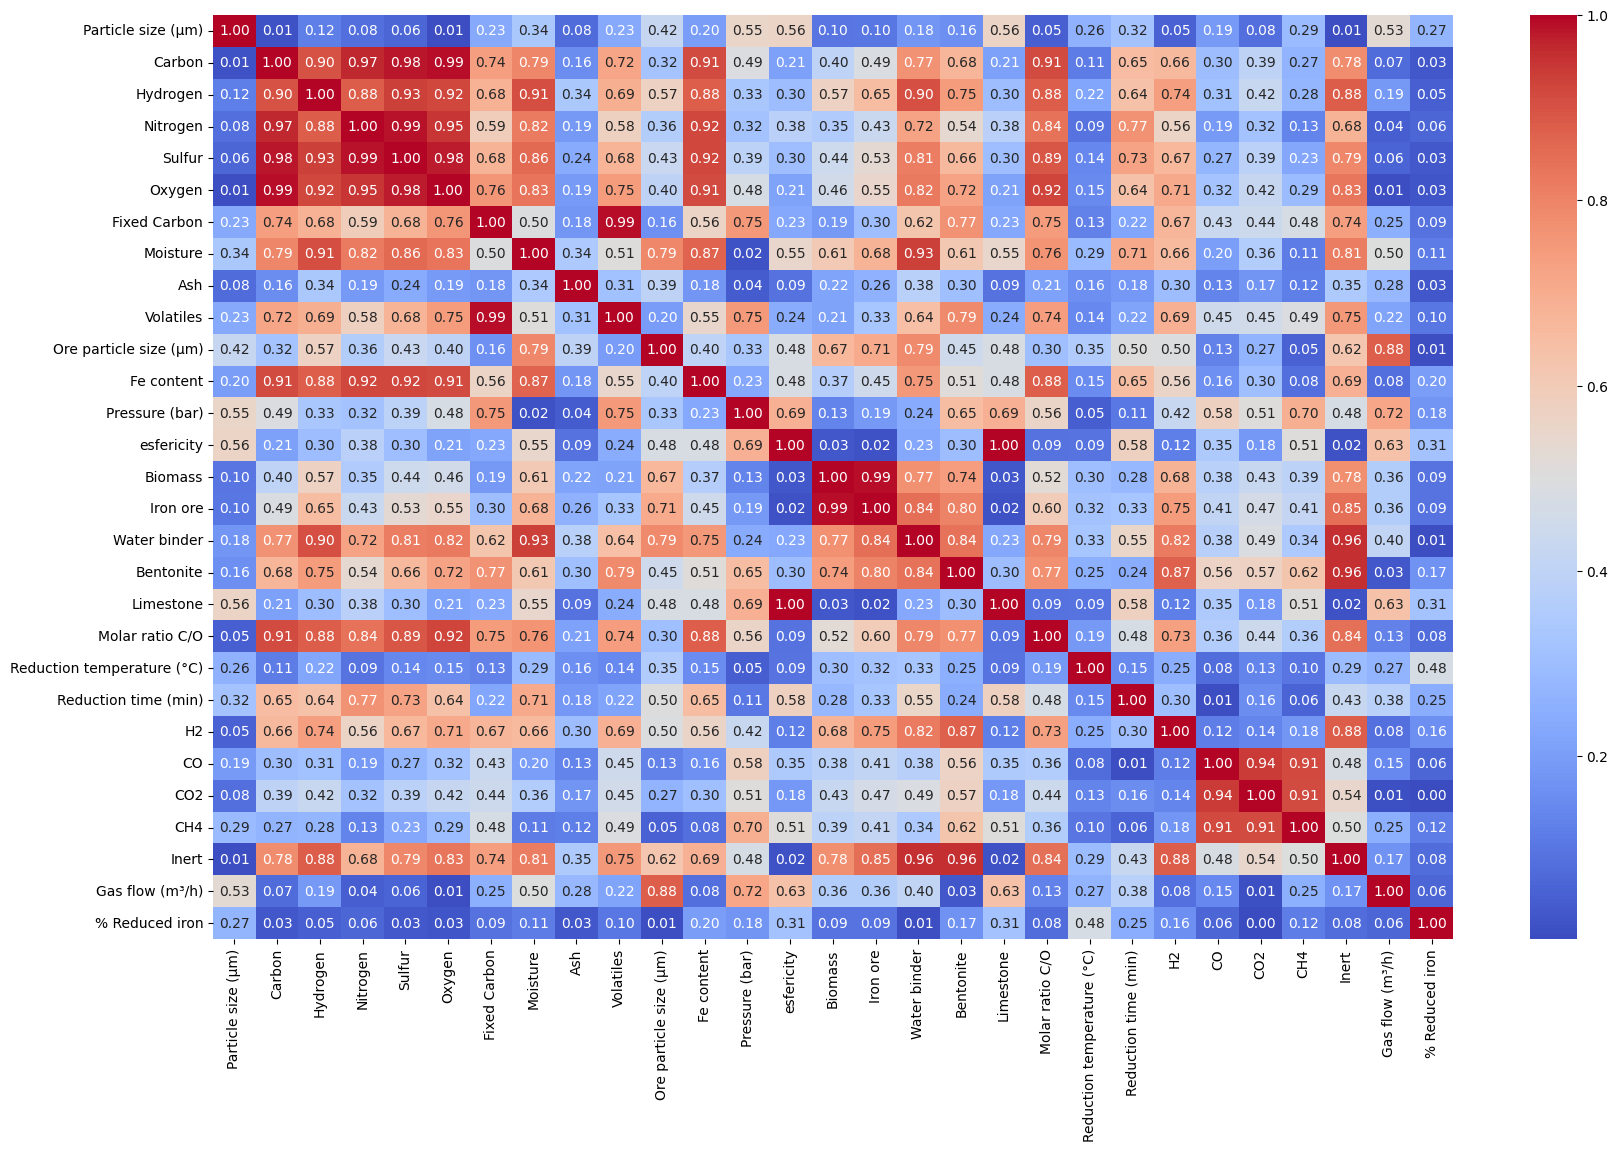

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(np.abs(correlation_matrix), annot=True, cmap='coolwarm', fmt=".2f")
#plt.title('Correlation Matrix of DataFrame Columns')
plt.show()

In [ ]:
((correlation_matrix[correlation_matrix.index=='% Reduced iron'].T**2)**0.5).sort_values('% Reduced iron',ascending=False)

In [ ]:
# MLP training

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from typing import Tuple


feature_cols = df.columns.drop('% Reduced iron')

target_col = '% Reduced iron'

X = df[feature_cols].values.astype(np.float32)
y = df[[target_col]].values.astype(np.float32)


n_bins = min(10, max(2, int(np.sqrt(len(y)))))
bins = pd.qcut(y.ravel(), q=n_bins, duplicates='drop', labels=False)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=bins
)

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))


class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dims, activation: str, dropout: float):
        super().__init__()
        acts = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "leakyrelu": nn.LeakyReLU(0.1),
            "gelu": nn.GELU(),
        }
        layers = []
        last = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(last, h), acts[activation], nn.Dropout(dropout)]
            last = h
        layers += [nn.Linear(last, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_loaders(train_ds, val_ds, batch_size: int) -> Tuple[DataLoader, DataLoader]:
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
    return train_loader, val_loader

def evaluate(model, loader, criterion):
    model.eval()
    y_true, y_pred = [], []
    loss_sum, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            loss_sum += loss.item() * len(xb)
            y_true.append(yb.detach().cpu().numpy())
            y_pred.append(out.detach().cpu().numpy())
            n += len(xb)
    y_true = np.vstack(y_true).ravel()
    y_pred = np.vstack(y_pred).ravel()
    mse = loss_sum / n
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return mse, mae, r2


def objective(trial: optuna.Trial) -> float:

    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_dims = []
    for i in range(n_layers):
        hidden_dims.append(trial.suggest_int(f"n_units_l{i+1}", 16, 512, log=True))
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "leakyrelu", "gelu"])
    dropout    = trial.suggest_float("dropout", 0.0, 0.4)
    lr         = trial.suggest_float("lr", 1e-5, 3e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size   = trial.suggest_categorical("batch_size", [32, 64, 128, 256])


    model = MLP(in_dim=X_train.shape[1], hidden_dims=hidden_dims,
                activation=activation, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    train_loader, val_loader = make_loaders(train_ds, val_ds, batch_size)


    best_val = float("inf")
    patience = 30
    wait = 0
    max_epochs = 1000

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()


        val_mse, val_mae, val_r2 = evaluate(model, val_loader, criterion)
        trial.report(val_mse, epoch)


        if trial.should_prune():
            raise optuna.TrialPruned()


        if val_mse < best_val - 1e-6:
            best_val = val_mse
            wait = 0
            best_state = {
                "model": model.state_dict(),
                "epoch": epoch,
                "val_mse": val_mse,
                "val_mae": val_mae,
                "val_r2": val_r2,
            }
        else:
            wait += 1
            if wait >= patience:
                break


    return best_val


study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_warmup_steps=20),
)
study.optimize(objective, n_trials=100, show_progress_bar=False)

print("Best trial:", study.best_trial.number)
print("Best value (val MSE):", study.best_value)
print("Best params:", study.best_params)


best = study.best_params
hidden_dims = [best[f"n_units_l{i+1}"] for i in range(best["n_layers"])]

model = MLP(X_train.shape[1], hidden_dims, best["activation"], best["dropout"]).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
criterion = nn.MSELoss()
train_loader, val_loader = make_loaders(train_ds, val_ds, best["batch_size"])

best_val, wait, patience = float("inf"), 0, 40
for epoch in range(1, 1000 + 1):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device); yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

    val_mse, val_mae, val_r2 = evaluate(model, val_loader, criterion)
    if val_mse < best_val - 1e-6:
        best_val = val_mse
        wait = 0
        best_state = {"model": model.state_dict(), "epoch": epoch}
    else:
        wait += 1
        if wait >= patience:
            break

model.load_state_dict(best_state["model"])


val_mse, val_mae, val_r2 = evaluate(model, val_loader, criterion)
print(f"[VAL] MSE: {val_mse:.6f} | MAE: {val_mae:.6f} | R2: {val_r2:.4f}")


def predict(model: nn.Module, Xnew: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        xb = torch.from_numpy(Xnew.astype(np.float32)).to(device)
        out = model(xb).detach().cpu().numpy()
    return out

In [ ]:
# Model performance metrics

mse_train, mae_train, r2_train = evaluate(model, train_loader, criterion)
mse_val, mae_val, r2_val = evaluate(model, val_loader, criterion)
rmse_train = np.sqrt(mse_train)
rmse_val = np.sqrt(mse_val)

print("-" * 45)
print(f"{'Indicator':<15} | {'Train':<12} | {'Test (Val)':<12}")
print("-" * 45)
print(f"{'RMSE':<15} | {rmse_train:<12.6f} | {rmse_val:<12.6f}")
print(f"{'MAE':<15} | {mae_train:<12.6f} | {mae_val:<12.6f}")
print(f"{'R²':<15} | {r2_train:<12.4f} | {r2_val:<12.4f}")
print("-" * 45)

print("\nSet of Hyperparameters:")
for param, val in study.best_params.items():
    print(f" > {param}: {val}")

In [ ]:
# Saving the model

checkpoint = {
    'model_state_dict': model.state_dict(),
    'hyperparameters': study.best_params,
    'metrics': {
        'train': {'rmse': rmse_train, 'mae': mae_train, 'r2': r2_train},
        'test': {'rmse': rmse_val, 'mae': mae_val, 'r2': r2_val}
    },
    'feature_cols': list(feature_cols)
}

torch.save(checkpoint, "Total_mlp_model.pth")

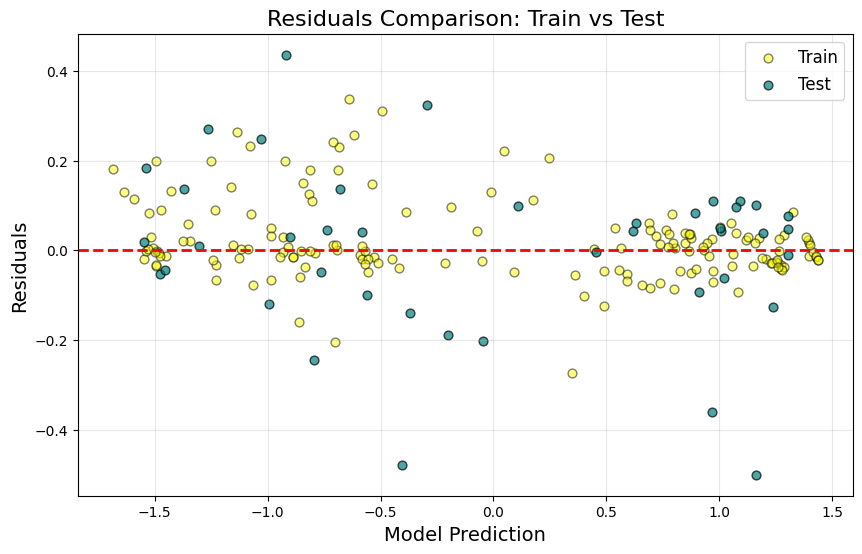

In [ ]:
# Comparative residuals
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_pred_train = model(torch.from_numpy(X_train).to(device)).cpu().detach().numpy().flatten()
    y_pred_val = model(torch.from_numpy(X_val).to(device)).cpu().detach().numpy().flatten()

res_train = y_train.ravel() - y_pred_train
res_val = y_val.ravel() - y_pred_val

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_train, res_train, alpha=0.5, color='yellow', label='Train', edgecolors='k', s=40)
plt.scatter(y_pred_val, res_val, alpha=0.7, color='teal', label='Test', edgecolors='k', s=40)
plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.xlabel('Model Prediction', size=14)
plt.ylabel('Residuals', size=14)
plt.title('Residuals Comparison: Train vs Test', size=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.show()

# 1.0 Making predictions

In [ ]:
# Identifying values out of the training range
import pandas as pd
import numpy as np

absolute_values = {
    'Particle size (µm)': 200,
    'Carbon': 0.4867, # Islam et al. (2010)
    'Hydrogen': 0.067, # Islam et al. (2010)
    'Nitrogen': 0.0045, # Islam et al. (2010)
    'Sulfur': 0.0008, # Islam et al. (2010)
    'Oxygen': 0.4410, # Islam et al. (2010)
    'Fixed Carbon': 0.201, # Islam et al. (2010)
    'Moisture': 0.10,
    'Ash': 0.0414, # Islam et al. (2010)
    'Volatiles': 0.7585, # Islam et al. (2010)
    'Ore particle size (µm)': 200,
    'Fe content': 0.65,
    'Pressure (bar)': 25,
    'esfericity': 0.85714,
    'Biomass': 0.4328,
    'Iron ore': 0.5672,
    'Water binder': 0,
    'Bentonite': 0,
    'Limestone': 0,
    'Molar ratio C/O': 1.25,
    'Reduction temperature (°C)': 1000,
    'Reduction time (min)': 15,
    'H2': 0.456,
    'CO': 0.362,
    'CO2': 0.123,
    'CH4': 0.059,
    'Inert': 0,
    'Gas flow (m³/h)': 0.03
}

for feature, value in absolute_values.items():
    original_min = df_original[feature].min()
    original_max = df_original[feature].max()

    is_in_range = (value >= original_min) and (value <= original_max)

    if not is_in_range:
        print(f"Out of range for {feature}: {value}. The range is: [{original_min:.4f}, {original_max:.4f}]")

Out of range for esfericity: 0.85714. The range is: [0.8686, 1.0000]


In [ ]:
# Obtaining the padronized values
# Get the mean and std values from the original data

original_mean_Particle_size = df_original['Particle size (µm)'].mean()
original_std_Particle_size = df_original['Particle size (µm)'].std()

original_mean_Carbon = df_original['Carbon'].mean()
original_std_Carbon = df_original['Carbon'].std()

original_mean_Hydrogen = df_original['Hydrogen'].mean()
original_std_Hydrogen = df_original['Hydrogen'].std()

original_mean_Nitrogen = df_original['Nitrogen'].mean()
original_std_Nitrogen = df_original['Nitrogen'].std()

original_mean_Sulfur = df_original['Sulfur'].mean()
original_std_Sulfur = df_original['Sulfur'].std()

original_mean_Oxygen = df_original['Oxygen'].mean()
original_std_Oxygen = df_original['Oxygen'].std()

original_mean_Fixed_Carbon = df_original['Fixed Carbon'].mean()
original_std_Fixed_Carbon = df_original['Fixed Carbon'].std()

original_mean_Moisture = df_original['Moisture'].mean()
original_std_Moisture = df_original['Moisture'].std()

original_mean_Ash = df_original['Ash'].mean()
original_std_Ash = df_original['Ash'].std()

original_mean_Volatiles = df_original['Volatiles'].mean()
original_std_Volatiles = df_original['Volatiles'].std()

original_mean_Ore_particle_size = df_original['Ore particle size (µm)'].mean()
original_std_Ore_particle_size = df_original['Ore particle size (µm)'].std()

original_mean_Fe_content = df_original['Fe content'].mean()
original_std_Fe_content = df_original['Fe content'].std()

original_mean_Pressure = df_original['Pressure (bar)'].mean()
original_std_Pressure = df_original['Pressure (bar)'].std()

original_mean_esfericity = df_original['esfericity'].mean()
original_std_esfericity = df_original['esfericity'].std()

original_mean_Biomass = df_original['Biomass'].mean()
original_std_Biomass = df_original['Biomass'].std()

original_mean_iron_ore = df_original['Iron ore'].mean()
original_std_iron_ore = df_original['Iron ore'].std()

original_mean_water_binder = df_original['Water binder'].mean()
original_std_water_binder = df_original['Water binder'].std()

original_mean_Bentonite = df_original['Bentonite'].mean()
original_std_Bentonite = df_original['Bentonite'].std()

original_mean_Limestone = df_original['Limestone'].mean()
original_std_Limestone = df_original['Limestone'].std()

original_mean_Molar_ratio_CO = df_original['Molar ratio C/O'].mean()
original_std_Molar_ratio_CO = df_original['Molar ratio C/O'].std()

original_mean_reduction_temperature = df_original['Reduction temperature (°C)'].mean()
original_std_reduction_temperature = df_original['Reduction temperature (°C)'].std()

original_mean_reduction_time = df_original['Reduction time (min)'].mean()
original_std_reduction_time = df_original['Reduction time (min)'].std()

original_mean_H2 = df_original['H2'].mean()
original_std_H2 = df_original['H2'].std()

original_mean_CO = df_original['CO'].mean()
original_std_CO = df_original['CO'].std()

original_mean_CO2 = df_original['CO2'].mean()
original_std_CO2 = df_original['CO2'].std()

original_mean_CH4 = df_original['CH4'].mean()
original_std_CH4 = df_original['CH4'].std()

original_mean_Inert = df_original['Inert'].mean()
original_std_Inert = df_original['Inert'].std()

original_mean_Gas_flow = df_original['Gas flow (m³/h)'].mean()
original_std_Gas_flow = df_original['Gas flow (m³/h)'].std()

original_mean_iron_reduction = df_original['% Reduced iron'].mean()
original_std_iron_reduction = df_original['% Reduced iron'].std()

# Absolute values
Particle_size = 200
Carbon = 0.4867 # Islam et al. (2010)
Hydrogen = 0.067 # Islam et al. (2010)
Nitrogen = 0.0045 # Islam et al. (2010)
Sulfur = 0.0008 # Islam et al. (2010)
Oxygen = 0.4410 # Islam et al. (2010)
Fixed_Carbon = 0.201 # Islam et al. (2010)
Moisture = 0.10
Ash = 0.0414 # Islam et al. (2010)
Volatiles = 0.7585 # Islam et al. (2010)
Ore_particle_size = 200
Fe_content = 0.65
Pressure = 25
esfericity = 0.85714
Biomass = 0.4328
Iron_ore = 0.5672
Water_binder = 0
Bentonite = 0
Limestone = 0
Molar_ratio_CO = 1.25
Reduction_temperature = 1000
Reduction_time = 15
H2 = 0.456 # Guo et al. (2017)
CO = 0.362 # Guo et al. (2017)
CO2 = 0.123 # Guo et al. (2017)
CH4 = 0.059 # Guo et al. (2017)
Inert = 0 # Guo et al. (2017)
Gas_flow = 0.03

# Calculating the padronized values
Particle_size_standardized = (Particle_size - original_mean_Particle_size) / original_std_Particle_size
Carbon_standardized = (Carbon - original_mean_Carbon) / original_std_Carbon
Hydrogen_standardized = (Hydrogen - original_mean_Hydrogen) / original_std_Hydrogen
Nitrogen_standardized = (Nitrogen - original_mean_Nitrogen) / original_std_Nitrogen
Sulfur_standardized = (Sulfur - original_mean_Sulfur) / original_std_Sulfur
Oxygen_standardized = (Oxygen - original_mean_Oxygen) / original_std_Oxygen
Fixed_Carbon_standardized = (Fixed_Carbon - original_mean_Fixed_Carbon) / original_std_Fixed_Carbon
Moisture_standardized = (Moisture - original_mean_Moisture) / original_std_Moisture
Ash_standardized = (Ash - original_mean_Ash) / original_std_Ash
Volatiles_standardized = (Volatiles - original_mean_Volatiles) / original_std_Volatiles
Ore_particle_size_standardized = (Ore_particle_size - original_mean_Ore_particle_size) / original_std_Ore_particle_size
Fe_content_standardized = (Fe_content - original_mean_Fe_content) / original_std_Fe_content
Pressure_standardized = (Pressure - original_mean_Pressure) / original_std_Pressure
esfericity_standardized = (esfericity - original_mean_esfericity) / original_std_esfericity
Biomass_standardized = (Biomass - original_mean_Biomass) / original_std_Biomass
Iron_ore_standardized = (Iron_ore - original_mean_iron_ore) / original_std_iron_ore
Water_binder_standardized = (Water_binder - original_mean_water_binder) / original_std_water_binder
Bentonite_standardized = (Bentonite - original_mean_Bentonite) / original_std_Bentonite
Limestone_standardized = (Limestone - original_mean_Limestone) / original_std_Limestone
Molar_ratio_CO_standardized = (Molar_ratio_CO - original_mean_Molar_ratio_CO) / original_std_Molar_ratio_CO
Reduction_temperature_standardized = (Reduction_temperature - original_mean_reduction_temperature) / original_std_reduction_temperature
Reduction_time_standardized = (Reduction_time - original_mean_reduction_time) / original_std_reduction_time
H2_standardized = (H2 - original_mean_H2) / original_std_H2
CO_standardized = (CO - original_mean_CO) / original_std_CO
CO2_standardized = (CO2 - original_mean_CO2) / original_std_CO2
CH4_standardized = (CH4 - original_mean_CH4) / original_std_CH4
Inert_standardized = (Inert - original_mean_Inert) / original_std_Inert
Gas_flow_standardized = (Gas_flow - original_mean_Gas_flow) / original_std_Gas_flow

print(f"Particle_size_standardized: {Particle_size_standardized:.4f}")
print(f"Carbon_standardized: {Carbon_standardized:.4f}")
print(f"Hydrogen_standardized: {Hydrogen_standardized:.4f}")
print(f"Nitrogen_standardized: {Nitrogen_standardized:.4f}")
print(f"Sulfur_standardized: {Sulfur_standardized:.4f}")
print(f"Oxygen_standardized: {Oxygen_standardized:.4f}")
print(f"Fixed_Carbon_standardized: {Fixed_Carbon_standardized:.4f}")
print(f"Moisture_standardized: {Moisture_standardized:.4f}")
print(f"Ash_standardized: {Ash_standardized:.4f}")
print(f"Volatiles_standardized: {Volatiles_standardized:.4f}")
print(f"Ore_particle_size_standardized: {Ore_particle_size_standardized:.4f}")
print(f"Fe_content_standardized: {Fe_content_standardized:.4f}")
print(f"Pressure_standardized: {Pressure_standardized:.4f}")
print(f"esfericity_standardized: {esfericity_standardized:.4f}")
print(f"Biomass_standardized: {Biomass_standardized:.4f}")
print(f"Iron_ore_standardized: {Iron_ore_standardized:.4f}")
print(f"Water_binder_standardized: {Water_binder_standardized:.4f}")
print(f"Bentonite_standardized: {Bentonite_standardized:.4f}")
print(f"Limestone_standardized: {Limestone_standardized:.4f}")
print(f"Molar_ratio_C_O_standardized: {Molar_ratio_CO_standardized:.4f}")
print(f"Reduction_temperature_standardized: {Reduction_temperature_standardized:.4f}")
print(f"Reduction_time_standardized: {Reduction_time_standardized:.4f}")
print(f"H2_standardized: {H2_standardized:.4f}")
print(f"CO_standardized: {CO_standardized:.4f}")
print(f"CO2_standardized: {CO2_standardized:.4f}")
print(f"CH4_standardized: {CH4_standardized:.4f}")
print(f"Inert_standardized: {Inert_standardized:.4f}")
print(f"Gas_flow_standardized: {Gas_flow_standardized:.4f}")

In [ ]:
import torch
import numpy as np

model.eval()

input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

input_array = np.array([input_data[feat] for feat in feature_cols], dtype=np.float32).reshape(1, -1)
print(feature_cols)
print(input_array)
input_tensor = torch.tensor(input_array, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred = model(input_tensor).cpu().numpy().flatten()[0]

print(f"Model prediction (standardized): {y_pred:.4f}")
predicted_reduction_mlp_absolute = y_pred * df_original['% Reduced iron'].std() + df_original['% Reduced iron'].mean()
print(f"Model prediction (absolute): {predicted_reduction_mlp_absolute:.4f}")

In [ ]:
# Conformal prediction for Confidence Interval
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X_val_tensor = torch.from_numpy(X_val).to(device)

model.eval()
with torch.no_grad():
    y_val_pred_std = model(X_val_tensor).cpu().numpy().flatten()

# Turning the values to the original scale
y_val_pred_abs = y_val_pred_std * df_original['% Reduced iron'].std() + df_original['% Reduced iron'].mean()
y_val_real_abs = y_val.ravel() * df_original['% Reduced iron'].std() + df_original['% Reduced iron'].mean()
residuos_calib = np.abs(y_val_real_abs - y_val_pred_abs)

# IQR method for confidence interval
alpha = 0.05
q_hat = np.percentile(residuos_calib, 100 * (1 - alpha))

print(f"Confidence interval: +/- {q_hat:.4f}")

# Histogram plot
plt.figure(figsize=(10, 6))
sns.histplot(residuos_calib, kde=True#, color='blue'
             )
plt.axvline(q_hat, color='red', linestyle='--', label=f'CI = {(1-alpha)*100} %')

plt.xlabel('Absolute Error', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.legend()
plt.show()

# 2.0 Making optimizations

In [ ]:
# Bayesian optimizator
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.9 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
from skopt import gp_minimize

random = 42

input_data = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

def objective_function_mlp(params):
    molar_ratio, temp, time, gas_flow = params
    current_df = input_data.copy()
    current_df['Molar ratio C/O'] = molar_ratio
    current_df['Reduction temperature (°C)'] = temp
    current_df['Reduction time (min)'] = time
    current_df['Gas flow (m³/h)'] = gas_flow

    input_np = current_df.values.astype(np.float32)
    input_tensor = torch.tensor(input_np).to(device)

    model.eval()
    with torch.no_grad():
        predicted_reduction_mlp = model(input_tensor).cpu().numpy().item()

    print(f"   -> Predicted Reduction: {predicted_reduction_mlp:.4f} | Objective Value: {-predicted_reduction_mlp:.4f}")

    return (-predicted_reduction_mlp)

space = [
    (df['Molar ratio C/O'].min(), df['Molar ratio C/O'].max()),
    (df['Reduction temperature (°C)'].min(), df['Reduction temperature (°C)'].max()),
    (df['Reduction time (min)'].min(), df['Reduction time (min)'].max()),
    (df['Gas flow (m³/h)'].min(), df['Gas flow (m³/h)'].max())
]

# Performing Bayesian Optimization
n_calls = 100
print("MLP model optimization is starting:")
result_mlp = gp_minimize(objective_function_mlp, space, n_calls=n_calls, random_state=random)

optimal_params_mlp = result_mlp.x
max_reduction_mlp = -result_mlp.fun
max_reduction_mlp_absolute = max_reduction_mlp * df_original['% Reduced iron'].std() + df_original['% Reduced iron'].mean()
optimal_molar_ratio_CO_absolute = optimal_params_mlp[0] * df_original['Molar ratio C/O'].std() + df_original['Molar ratio C/O'].mean()
optimal_reduction_temperature_absolute = optimal_params_mlp[1] * df_original['Reduction temperature (°C)'].std() + df_original['Reduction temperature (°C)'].mean()
optimal_reduction_time_absolute = optimal_params_mlp[2] * df_original['Reduction time (min)'].std() + df_original['Reduction time (min)'].mean()
optimal_gas_flow_absolute = optimal_params_mlp[3] * df_original['Gas flow (m³/h)'].std() + df_original['Gas flow (m³/h)'].mean()

print(f"Optimal Parameters for MLP Model: {optimal_params_mlp}")
print(f"Maximum % Reduced Iron for MLP Model: {max_reduction_mlp}")

print(f"Maximum % Reduced Iron (Absolute) for MLP Model: {max_reduction_mlp_absolute:.2f}")
print(f"Optimal Molar Ratio C/O (Absolute): {optimal_molar_ratio_CO_absolute:.2f}")
print(f"Optimal Reduction Temperature (Absolute): {optimal_reduction_temperature_absolute:.2f}")
print(f"Optimal Reduction Time (Absolute): {optimal_reduction_time_absolute:.2f}")
print(f"Optimal Gas Flow (Absolute): {optimal_gas_flow_absolute:.2f}")

# 3.0 Surface responses

In [ ]:
!pip install plotly
!pip install jupyter-dash

In [ ]:
# Iron Reduction x Temperature (°C) and time (min)

import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

def plot_mlp_response_surface(model, model_name,
                              param_fixed_values_std,
                              temp_range_raw,
                              time_range_raw,
                              n_points,
                              stats_z,
                              stats_temp,
                              stats_time,
                              feature_cols):

    # Grid mesh
    Temp_grid_raw, Time_grid_raw = np.meshgrid(temp_range_raw, time_range_raw)
    total_points = n_points**2

    surface_base_df = pd.DataFrame(param_fixed_values_std)
    surface_data = pd.concat([surface_base_df] * total_points, ignore_index=True)
    surface_data['Reduction temperature (°C)'] = (Temp_grid_raw.flatten() - stats_temp['mean']) / stats_temp['std']
    surface_data['Reduction time (min)'] = (Time_grid_raw.flatten() - stats_time['mean']) / stats_time['std']

    X_input_np = surface_data[feature_cols].values.astype(np.float32)
    X_input_tensor = torch.from_numpy(X_input_np).to(device)

    model.eval()
    with torch.no_grad():
        predictions_std = model(X_input_tensor).cpu().numpy().flatten()

    Z_absolute = (predictions_std * stats_z['std']) + stats_z['mean']
    Z_plot = Z_absolute.reshape(n_points, n_points)

    # Plot
    fig = go.Figure(data=[
        go.Surface(
            x=temp_range_raw,
            y=time_range_raw,
            z=Z_plot,
            colorscale='Viridis',
            colorbar=dict(title='Iron Reduction')
        )
    ])

    fig.update_layout(
        title=f'3D Response Surface (MLP): {model_name}',
        scene=dict(
            xaxis=dict(title='Reduction temperature (°C)'),
            yaxis=dict(title='Reduction time (min)'),
            zaxis=dict(title='Iron Reduction')
        ),
        width=900,
        height=800,
        margin=dict(l=65, r=50, b=65, t=90)
    )

    # Exporting the graph
    html_file_name = f'Surface_MLP_Absolute_{model_name}.html'
    pio.write_html(fig, html_file_name, auto_open=True)
    print(f"MLP graph saved as '{html_file_name}'.")

In [ ]:
param_fixed_values = pd.DataFrame({
        'Particle size (µm)': [Particle_size_standardized],
        'Carbon': [Carbon_standardized],
        'Hydrogen': [Hydrogen_standardized],
        'Nitrogen': [Nitrogen_standardized],
        'Sulfur': [Sulfur_standardized],
        'Oxygen': [Oxygen_standardized],
        'Fixed Carbon': [Fixed_Carbon_standardized],
        'Moisture': [Moisture_standardized],
        'Ash': [Ash_standardized],
        'Volatiles': [Volatiles_standardized],
        'Ore particle size (µm)': [Ore_particle_size_standardized],
        'Fe content': [Fe_content_standardized],
        'Pressure (bar)': [Pressure_standardized],
        'esfericity': [esfericity_standardized],
        'Biomass': [Biomass_standardized],
        'Iron ore': [Iron_ore_standardized],
        'Water binder': [Water_binder_standardized],
        'Bentonite': [Bentonite_standardized],
        'Limestone': [Limestone_standardized],
        'Molar ratio C/O': [Molar_ratio_CO_standardized],
        'Reduction temperature (°C)': [Reduction_temperature_standardized],
        'Reduction time (min)': [Reduction_time_standardized],
        'H2': [H2_standardized],  # Guo et al. (2017)
        'CO': [CO_standardized],  # Guo et al. (2017)
        'CO2': [CO2_standardized],  # Guo et al. (2017)
        'CH4': [CH4_standardized],  # Guo et al. (2017)
        'Inert': [Inert_standardized],  # Guo et al. (2017)
        'Gas flow (m³/h)': [Gas_flow_standardized]
    })

# Mesh range
n_points = 50
temp_range = np.linspace(df_original['Reduction temperature (°C)'].min(), df_original['Reduction temperature (°C)'].max(), n_points)
time_range = np.linspace(df_original['Reduction time (min)'].min(), df_original['Reduction time (min)'].max(), n_points)

stats_temp = {
    'mean': df_original['Reduction temperature (°C)'].mean(),
    'std': df_original['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df_original['Reduction time (min)'].mean(),
    'std': df_original['Reduction time (min)'].std(ddof=0)
}

stats_z = {
    'mean': df_original['% Reduced iron'].mean(),
    'std': df_original['% Reduced iron'].std(ddof=0)
}

# Running the plot function
plot_mlp_response_surface(
     model.eval(),
     "Total_MLP_Model",
     param_fixed_values,
     temp_range,
     time_range,
     n_points,
     stats_z,
     stats_temp,
     stats_time,
     feature_cols
)

Sucesso! Gráfico MLP salvo como 'Surface_MLP_Absolute_Total_MLP_Model.html'.


# 4.0 Shapley Analysis

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
import torch

def permutation_importance(model, X, y, baseline_mse=None, n_repeats=5):
    model.eval()
    X = X.copy()
    y_pred = model(torch.from_numpy(X).float().to(device)).detach().cpu().numpy()
    if baseline_mse is None:
        baseline_mse = mean_squared_error(y, y_pred)

    importances = np.zeros(X.shape[1])
    for i in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            np.random.shuffle(X_permuted[:, i])
            y_perm = model(torch.from_numpy(X_permuted).float().to(device)).detach().cpu().numpy()
            mse_perm = mean_squared_error(y, y_perm)
            scores.append(mse_perm - baseline_mse)
        importances[i] = np.mean(scores)
    return importances


importances = permutation_importance(model, X_val, y_val)
feat_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

print(feat_importance.head(10))

feat_importance.head(15).plot(kind='barh', figsize=(8,6), color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("ΔMSE (Relative importance)")
plt.title("Permutation Feature Importance")
plt.show()


In [ ]:
feat_importance.index.to_list()

In [ ]:
import torch
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model.eval()

X = df[feature_cols].values.astype(np.float32)
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

sample_size = max(1, int(0.2 * len(X)))
idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X_tensor[idx]
#X_sample = X_val

def model_predict(x_numpy):
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(x_tensor).cpu().numpy()
    return preds

try:
    explainer = shap.DeepExplainer(model, X_sample)
    shap_values = explainer.shap_values(X_sample)
except Exception as e:
    print(" DeepExplainer failed ... using the KernelExplainer ...")
    explainer = shap.KernelExplainer(model_predict, shap.sample(X, 100))
    shap_values = explainer.shap_values(X_sample.cpu().numpy(), nsamples=100)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

if shap_values.ndim == 3 and shap_values.shape[2] == 1:
    shap_values = shap_values.squeeze(axis=2)

assert shap_values.shape[1] == len(feature_cols), \
    f"Wrong dimension: it was expected {len(feature_cols)} columns, but it was achieved {shap_values.shape[1]}"

# Shap values
shap_importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Mean(|SHAP|)": shap_importance
}).sort_values("Mean(|SHAP|)", ascending=False).reset_index(drop=True)

print("\nMean features importance (SHAP):")
print(importance_df)

# Graph plot
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Mean(|SHAP|)"], color="royalblue")
plt.gca().invert_yaxis()
plt.xlabel("Mean importance (SHAP)")
plt.title("Features relevance (SHAP)")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_sample.cpu().numpy(), feature_names=feature_cols)

In [ ]:
importance_df

In [ ]:
# Achieveing the higher R² score - Recursive Feature Elimination

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Hyperparameters of the Total MLP
best_params = study.best_params
hidden_dims_fixed = [best_params[f"n_units_l{i+1}"] for i in range(best_params["n_layers"])]
activation_fixed = best_params["activation"]
dropout_fixed = best_params["dropout"]
lr_fixed = best_params["lr"]
batch_size_fixed = best_params["batch_size"]

ordered_features = importance_df['Feature'].tolist()

def make_loaders(X, y, batch_size):
    tx = torch.from_numpy(X.astype(np.float32))
    ty = torch.from_numpy(y.astype(np.float32))
    ds = TensorDataset(tx, ty)
    return DataLoader(ds, batch_size=batch_size, shuffle=True)

def evaluate_complete(model, X_val, y_val):
    model.eval()
    with torch.no_grad():
        Xv = torch.from_numpy(X_val.astype(np.float32)).to(device)
        pred = model(Xv).cpu().numpy()

    mse = mean_squared_error(y_val, pred)
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)
    return mse, mae, r2, pred

# Recursive Features Elimination - RFE
results_rfe = []

for n in range(len(ordered_features), 0, -1):
    selected = ordered_features[:n]
    print(f"\n[Round {len(ordered_features)-n+1}]. Training with {n} features...")

    X_sel = df[selected].values
    y_sel = df[target_col].values.reshape(-1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_sel, y_sel, test_size=0.2, random_state=SEED,
        stratify=pd.qcut(y_sel.ravel(), q=8, duplicates='drop', labels=False)
    )

    model_rfe = MLP(in_dim=n,
                    hidden_dims=hidden_dims_fixed,
                    activation=activation_fixed,
                    dropout=dropout_fixed).to(device)

    optimizer = torch.optim.AdamW(model_rfe.parameters(), lr=lr_fixed)
    criterion = nn.MSELoss()
    train_loader = make_loaders(X_train, y_train, batch_size_fixed)

    best_val_mse = float('inf')
    patience, wait = 40, 0

    for epoch in range(1, 1001):
        model_rfe.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model_rfe(xb), yb)
            loss.backward()
            optimizer.step()

        val_mse, _, _, _ = evaluate_complete(model_rfe, X_test, y_test)

        if val_mse < best_val_mse - 1e-6:
            best_val_mse = val_mse
            best_state = model_rfe.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience: break

    model_rfe.load_state_dict(best_state)

    mse_tr, mae_tr, r2_tr, _ = evaluate_complete(model_rfe, X_train, y_train)
    mse_te, mae_te, r2_te, _ = evaluate_complete(model_rfe, X_test, y_test)

    results_rfe.append({
        "n_features": n,
        "features_list": list(selected),
        "RMSE_Train": np.sqrt(mse_tr),
        "MAE_Train": mae_tr,
        "R2_Train": r2_tr,
        "RMSE_Test": np.sqrt(mse_te),
        "MAE_Test": mae_te,
        "R2_Test": r2_te
    })

    print(f"Final set: R2_Train: {r2_tr:.4f} | R2_Test: {r2_te:.4f}")

df_rfe_final = pd.DataFrame(results_rfe)
df_rfe_final.to_excel("rfe_mlp_fixo_results.xlsx", index=False)

# Graph
plt.figure(figsize=(10, 6))
plt.plot(df_rfe_final["n_features"], df_rfe_final["R2_Train"], 'o-', label="R² Train", alpha=0.6)
plt.plot(df_rfe_final["n_features"], df_rfe_final["R2_Test"], 's-', label="R² Test")
plt.xlabel('Remaining features', fontsize=14)
plt.ylabel('R²', fontsize=14)
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
best_round = df_rfe_final.loc[df_rfe_final['RMSE_Test'].idxmin()]

n_features_best = best_round['n_features']
features_remaining = best_round['features_list']

print("-" * 50)
print(f"Best set achieved: ({n_features_best} features)")
print("-" * 50)

print(f"{'Metric':<10} | {'Train':<12} | {'Test':<12}")
print("-" * 40)
print(f"{'RMSE':<10} | {best_round['RMSE_Train']:<12.6f} | {best_round['RMSE_Test']:<12.6f}")
print(f"{'MAE':<10} | {best_round['MAE_Train']:<12.6f} | {best_round['MAE_Test']:<12.6f}")
print(f"{'R²':<10} | {best_round['R2_Train']:<12.4f} | {best_round['R2_Test']:<12.4f}")

print("-" * 50)
print(f"List of the {n_features_best} remaining features:")
for i, f in enumerate(features_remaining, 1):
    print(f"{i}. {f}")
print("-" * 50)

In [ ]:
# Graph
import matplotlib.pyplot as plt

def plot_mlp_rfe_single_axis(df_results):
    plt.figure(figsize=(10, 6))

    plt.plot(df_results['n_features'], df_results['R2_Test'],
             marker='o', label='R² Test', color='blue', linewidth=2)

    plt.plot(df_results['n_features'], df_results['MAE_Test'],
             marker='s', label='MAE Test', color='orange', alpha=0.6)

    plt.gca().invert_xaxis()
    plt.xlabel('Remaining features', fontsize=18)
    plt.legend(prop={'size': 14}, loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_mlp_rfe_single_axis(df_rfe_final)

In [ ]:
# Shap analysis: feature by feature

import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def predict_mlp(x_numpy):
    model_total.eval()
    with torch.no_grad():
        x_tensor = torch.from_numpy(x_numpy.astype(np.float32)).to(device)
        pred = model_total(x_tensor).cpu().numpy()
    return pred.flatten()

background_summary = shap.kmeans(X_train_f, 10)
explainer = shap.KernelExplainer(predict_mlp, background_summary)

test_samples_for_shap = X_val_f[:100]
shap_values_mlp = explainer.shap_values(test_samples_for_shap)

X_test_absolute = pd.DataFrame(test_samples_for_shap, columns=feature_cols).copy()
stats_temp = {
    'mean': df_original['Reduction temperature (°C)'].mean(),
    'std': df_original['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df_original['Reduction time (min)'].mean(),
    'std': df_original['Reduction time (min)'].std(ddof=0)
}

stats_H2 = {
    'mean': df_original['H2'].mean(),
    'std': df_original['H2'].std(ddof=0)
}

stats_CO = {
    'mean': df_original['CO'].mean(),
    'std': df_original['CO'].std(ddof=0)
}

stats_fixed_carbon = {
    'mean': df_original['Fixed Carbon'].mean(),
    'std': df_original['Fixed Carbon'].std(ddof=0)
}

cols_map = {'Reduction temperature (°C)': stats_temp, 'H2': stats_H2}
for col, stats in cols_map.items():
    if col in X_test_absolute.columns:
        X_test_absolute[col] = (X_test_absolute[col] * stats['std']) + stats['mean']

# Graph PLot
main_feature = 'Reduction temperature (°C)'
secondary_feature = 'H2'
idx_principal = list(feature_cols).index(main_feature)

cols_to_desnorm = {
    'Reduction temperature (°C)': stats_temp,
    'H2': stats_H2
}

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind=idx_principal,
    shap_values=shap_values_mlp,
    features=X_test_absolute.values,
    feature_names=list(feature_cols),
    interaction_index=secondary_feature,
    display_features=X_test_absolute
)
plt.show()

In [ ]:
# Saving the Shap MLP Model
import torch

model_save_path = "best_mlp_model_18_features.pth"

checkpoint = {
    'model_state_dict': model_best.state_dict(),
    'features': selected_features,
    'n_features': n_best,
    'hyperparameters': {
        'hidden_dims': hidden_dims,
        'activation': best_params["activation"],
        'dropout': best_params["dropout"]
    },
    'scaler_info': {
        'mean': df_original['% Reduced iron'].mean(),
        'std': df_original['% Reduced iron'].std()
    },
    'metrics': metrics
}

torch.save(checkpoint, model_save_path)

print(f"Model succesfully saved as: {model_save_path}")

# Shapley MLP Model Training

# 1.0 Making predictions

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

n_best = 10
selected_features = ordered_features[:n_best]

X_sel = df[selected_features].values
y_sel = df[target_col].values.reshape(-1, 1)

X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
    X_sel, y_sel, test_size=0.2, random_state=SEED,
    stratify=pd.qcut(y_sel.ravel(), q=8, duplicates='drop', labels=False)
)

hidden_dims = [best_params[f"n_units_l{i+1}"] for i in range(best_params["n_layers"])]
model_best = MLP(in_dim=n_best,
                 hidden_dims=hidden_dims,
                 activation=best_params["activation"],
                 dropout=best_params["dropout"]).to(device)

optimizer = torch.optim.AdamW(model_best.parameters(), lr=best_params["lr"])
criterion = nn.MSELoss()
train_loader = make_loaders(X_test_best, y_test_best, best_params["batch_size"])

best_val_mse = float('inf')
for epoch in range(1, 1001):
    model_best.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(); criterion(model_best(xb), yb).backward(); optimizer.step()

    model_best.eval()
    with torch.no_grad():
        v_mse = criterion(model_best(torch.from_numpy(X_test_best.astype(np.float32)).to(device)),
                          torch.from_numpy(y_test_best.astype(np.float32)).to(device)).item()
    if v_mse < best_val_mse:
        best_val_mse = v_mse
        best_state_18 = model_best.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= 40: break

model_best.load_state_dict(best_state_18)

model_best.eval()
with torch.no_grad():
    y_pred_std = model_best(torch.from_numpy(X_test_best.astype(np.float32)).to(device)).cpu().numpy().flatten()

y_pred_abs = y_pred_std * df_original['% Reduced iron'].std() + df_original['% Reduced iron'].mean()
y_real_abs = y_test_best.flatten() * df_original['% Reduced iron'].std() + df_original['% Reduced iron'].mean()

# Graph plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_real_abs, y=y_pred_abs, alpha=0.6
                #, label='Predicted Points', color='royalblue'
                )

plt.plot([0, 1], [0, 1], 'r--', lw=2) # 45° straight line

plt.xlabel('Original', fontsize=18)
plt.ylabel('Predicted', fontsize=18)
#plt.title(f'MLP Performance with {n_best} Features', fontsize=15)
plt.legend()
plt.grid(True)

# Add text box for metrics
plt.text(0.05, 0.95, f'Shapley MLP regressor',
         bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5),
         horizontalalignment='left', verticalalignment='top',
         transform=plt.gca().transAxes,
         fontsize=16)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

mse_tr, mae_tr, r2_tr, _ = evaluate_complete(model_best, X_train_best, y_train_best)
mse_te, mae_te, r2_te, _ = evaluate_complete(model_best, X_test_best, y_test_best)

print(f"{'Metric':<10} | {'Train':<12} | {'Test':<12}")
print("-" * 40)
print(f"{'RMSE':<10} | {best_round['RMSE_Train']:<12.6f} | {best_round['RMSE_Test']:<12.6f}")
print(f"{'MAE':<10} | {best_round['MAE_Train']:<12.6f} | {best_round['MAE_Test']:<12.6f}")
print(f"{'R²':<10} | {best_round['R2_Train']:<12.4f} | {best_round['R2_Test']:<12.4f}")
print("-" * 50)

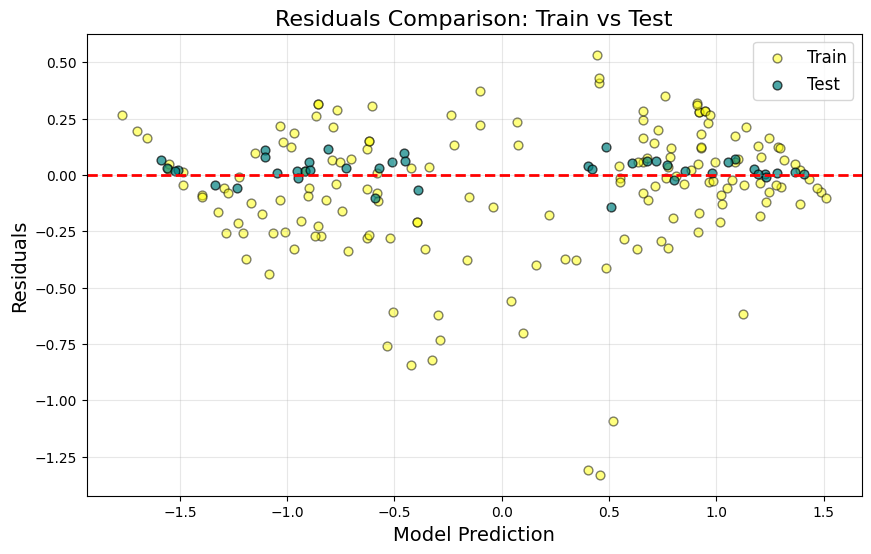

In [ ]:
# Comparative residuals
import matplotlib.pyplot as plt

model_best.eval()
with torch.no_grad():
    y_pred_val = model_best(torch.from_numpy(X_test_best.astype(np.float32)).to(device)).cpu().numpy().flatten()
    y_pred_train = model_best(torch.from_numpy(X_train_best.astype(np.float32)).to(device)).cpu().numpy().flatten()

res_val = y_test_best.flatten() - y_pred_val
res_train = y_train_best.flatten() - y_pred_train

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_train, res_train, alpha=0.5, color='yellow', label='Train', edgecolors='k', s=40)
plt.scatter(y_pred_val, res_val, alpha=0.7, color='teal', label='Test', edgecolors='k', s=40)
plt.axhline(y=0, color='r', linestyle='--', lw=2)

plt.xlabel('Model Prediction', size=14)
plt.ylabel('Residuals', size=14)
plt.title('Residuals Comparison: Train vs Test', size=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.show()

In [ ]:
import torch
import numpy as np

model_best.eval() # Put the right model name for Shapley MLP Model

inputs_std_dict = {
    'Particle size (µm)': Particle_size_standardized,
    'Carbon': Carbon_standardized,
    'Hydrogen': Hydrogen_standardized,
    'Nitrogen': Nitrogen_standardized,
    'Sulfur': Sulfur_standardized,
    'Oxygen': Oxygen_standardized,
    'Fixed Carbon': Fixed_Carbon_standardized,
    'Moisture': Moisture_standardized,
    'Ash': Ash_standardized,
    'Volatiles': Volatiles_standardized,
    'Ore particle size (µm)': Ore_particle_size_standardized,
    'Fe content': Fe_content_standardized,
    'Pressure (bar)': Pressure_standardized,
    'esfericity': esfericity_standardized,
    'Biomass': Biomass_standardized,
    'Iron ore': Iron_ore_standardized,
    'Water binder': Water_binder_standardized,
    'Bentonite': Bentonite_standardized,
    'Limestone': Limestone_standardized,
    'Molar ratio C/O': Molar_ratio_CO_standardized,
    'Reduction temperature (°C)': Reduction_temperature_standardized,
    'Reduction time (min)': Reduction_time_standardized,
    'H2': H2_standardized,
    'CO': CO_standardized,
    'CO2': CO2_standardized,
    'CH4': CH4_standardized,
    'Inert': Inert_standardized,
    'Gas flow (m³/h)': Gas_flow_standardized
}

# Filtering the selected features
input_list = [inputs_std_dict[feat] for feat in selected_features]
input_array = np.array(input_list, dtype=np.float32).reshape(1, -1)
input_tensor = torch.from_numpy(input_array).to(device)

with torch.no_grad():
    y_pred_std = model_best(input_tensor).cpu().numpy().flatten()[0]

y_pred_abs = y_pred_std * df_original['% Reduced iron'].std() + df_original['% Reduced iron'].mean()

print(f"Prediction (Standardized): {y_pred_std:.4f}")
print(f"Prediction (Absolute): {y_pred_abs:.4f}")

In [ ]:
# Confidence Interval

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

model_best.eval() # Put the right model name for Shapley MLP Model

X_test_tensor = torch.from_numpy(X_test_best.astype(np.float32)).to(device)

with torch.no_grad():
    y_pred_std = model_best(X_test_tensor).cpu().numpy().flatten()

std_iron = df_original['% Reduced iron'].std()
mean_iron = df_original['% Reduced iron'].mean()

y_pred_abs = y_pred_std * std_iron + mean_iron
y_real_abs = y_test_best.flatten() * std_iron + mean_iron

residuos_calib = np.abs(y_real_abs - y_pred_abs)
alpha = 0.05
q_hat = np.percentile(residuos_calib, 100 * (1 - alpha))

print(f"--- Results (n={n_best}) ---")
print(f"Quantil (q_hat) for {int((1-alpha)*100)}%. C.I.: +/- {q_hat:.4f}")

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(residuos_calib, kde=True)
plt.axvline(q_hat, color='red', linestyle='--', label=f'CI = {(1-alpha)*100} %')

plt.xlabel('Absolute error', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.legend()
plt.show()

# 2.0 Shapley Analysis

In [ ]:
import torch
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

checkpoint = torch.load("best_mlp_model_18_features.pth", weights_only=False)

selected_features = checkpoint['features']
n_best = checkpoint['n_features']
h_params = checkpoint['hyperparameters']

model_best = MLP(
    in_dim=n_best,
    hidden_dims=h_params['hidden_dims'],
    activation=h_params['activation'],
    dropout=h_params['dropout']
).to(device)

model_best.load_state_dict(checkpoint['model_state_dict'])
model_best.eval()

X_18 = df[selected_features].values.astype(np.float32)

sample_size = max(1, int(0.2 * len(X_18)))
idx = np.random.choice(len(X_18), size=sample_size, replace=False)
X_sample_18 = X_18[idx]

def model_predict_18(x_numpy):
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model_best(x_tensor).cpu().numpy()
    return preds.flatten()

background_18 = shap.kmeans(X_18, 10)
explainer = shap.KernelExplainer(model_predict_18, background_18)

shap_values_18 = explainer.shap_values(X_sample_18, nsamples=100)

if isinstance(shap_values_18, list):
    shap_values_18 = shap_values_18[0]
if shap_values_18.ndim == 3:
    shap_values_18 = shap_values_18.squeeze()

shap_importance = np.abs(shap_values_18).mean(axis=0)

importance_df_18 = pd.DataFrame({
    "Feature": selected_features,
    "Mean(|SHAP|)": shap_importance
}).sort_values("Mean(|SHAP|)", ascending=False).reset_index(drop=True)

print("\nMean Feature importance of selected features:")
print(importance_df_18)

# Graph plot
plt.figure(figsize=(10, 7))
plt.barh(importance_df_18["Feature"], importance_df_18["Mean(|SHAP|)"], color="seagreen")
plt.gca().invert_yaxis()
plt.xlabel("Mean(|SHAP|) (Impact on Model Output)")
plt.title(f"Feature Importance - Reduced MLP ({n_best} variables)")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_18, X_sample_18, feature_names=selected_features)

In [ ]:
# Shap analysis: feature by feature

import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_best.eval()
features_18 = selected_features

X_all_18 = df[features_18].values.astype(np.float32)

_, X_val_18 = train_test_split(
    X_all_18, test_size=0.2, random_state=SEED,
    stratify=pd.qcut(df[target_col].values.ravel(), q=8, duplicates='drop', labels=False)
)

def predict_mlp_18(x_numpy):
    with torch.no_grad():
        x_tensor = torch.from_numpy(x_numpy.astype(np.float32)).to(device)
        pred = model_best(x_tensor).cpu().numpy()
    return pred.flatten()

background_summary = shap.kmeans(X_all_18, 10)
explainer = shap.KernelExplainer(predict_mlp_18, background_summary)

test_samples_for_shap = X_val_18[:100]
shap_values_18 = explainer.shap_values(test_samples_for_shap)

X_test_absolute = pd.DataFrame(test_samples_for_shap, columns=features_18).copy()
stats_temp = {
    'mean': df_original['Reduction temperature (°C)'].mean(),
    'std': df_original['Reduction temperature (°C)'].std(ddof=0)
}

stats_time = {
    'mean': df_original['Reduction time (min)'].mean(),
    'std': df_original['Reduction time (min)'].std(ddof=0)
}

stats_H2 = {
    'mean': df_original['H2'].mean(),
    'std': df_original['H2'].std(ddof=0)
}

stats_fixed_carbon = {
    'mean': df_original['Fixed Carbon'].mean(),
    'std': df_original['Fixed Carbon'].std(ddof=0)
}

# Features pair
cols_map = {
    'Reduction temperature (°C)': stats_temp,
    'H2': stats_H2
}

for col, stats in cols_map.items():
    if col in X_test_absolute.columns:
        X_test_absolute[col] = (X_test_absolute[col] * stats['std']) + stats['mean']

# Plot
main_feature = 'Reduction temperature (°C)'
secondary_feature = 'H2'

idx_principal = list(features_18).index(main_feature)

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind=idx_principal,
    shap_values=shap_values_18,
    features=X_test_absolute.values,
    feature_names=list(features_18),
    interaction_index=secondary_feature,
    display_features=X_test_absolute
)
plt.show()

# 3.0 Making optimizations

In [ ]:
# Performing objective functions to maximize the % Reduced
!pip install scikit-optimize

In [ ]:
import torch
import numpy as np
import pandas as pd
from skopt import gp_minimize

base_std_dict = {
    'Particle size (µm)': Particle_size_standardized,
    'Carbon': Carbon_standardized,
    'Hydrogen': Hydrogen_standardized,
    'Nitrogen': Nitrogen_standardized,
    'Sulfur': Sulfur_standardized,
    'Oxygen': Oxygen_standardized,
    'Fixed Carbon': Fixed_Carbon_standardized,
    'Moisture': Moisture_standardized,
    'Ash': Ash_standardized,
    'Volatiles': Volatiles_standardized,
    'Ore particle size (µm)': Ore_particle_size_standardized,
    'Fe content': Fe_content_standardized,
    'Pressure (bar)': Pressure_standardized,
    'esfericity': esfericity_standardized,
    'Biomass': Biomass_standardized,
    'Iron ore': Iron_ore_standardized,
    'Water binder': Water_binder_standardized,
    'Bentonite': Bentonite_standardized,
    'Limestone': Limestone_standardized,
    'Molar ratio C/O': Molar_ratio_CO_standardized,
    'Reduction temperature (°C)': Reduction_temperature_standardized,
    'Reduction time (min)': Reduction_time_standardized,
    'H2': H2_standardized,
    'CO': CO_standardized,
    'CO2': CO2_standardized,
    'CH4': CH4_standardized,
    'Inert': Inert_standardized,
    'Gas flow (m³/h)': Gas_flow_standardized
}

# Selecting the "selected features"
def objective_function_mlp_18(params):
    molar_ratio, temp, time, gas_flow = params

    current_std_dict = base_std_dict.copy()
    current_std_dict['Molar ratio C/O'] = molar_ratio
    current_std_dict['Reduction temperature (°C)'] = temp
    current_std_dict['Reduction time (min)'] = time
    current_std_dict['Gas flow (m³/h)'] = gas_flow

    input_list = [current_std_dict[feat] for feat in selected_features]

    input_np = np.array(input_list, dtype=np.float32).reshape(1, -1)
    input_tensor = torch.from_numpy(input_np).to(device)

    model_best.eval()
    with torch.no_grad():
        predicted_reduction_std = model_best(input_tensor).cpu().numpy().item()

    return -predicted_reduction_std

# Search space
space = [
    (df['Molar ratio C/O'].min(), df['Molar ratio C/O'].max()),
    (df['Reduction temperature (°C)'].min(), df['Reduction temperature (°C)'].max()),
    (df['Reduction time (min)'].min(), df['Reduction time (min)'].max()),
    (df['Gas flow (m³/h)'].min(), df['Gas flow (m³/h)'].max())
]

n_calls = 100
print(f"Shapley MLP Optimization ({n_best} features) has started...")
result_mlp = gp_minimize(objective_function_mlp_18, space, n_calls=n_calls, random_state=random)

optimal_params_std = result_mlp.x
max_reduction_std = -result_mlp.fun

def reverse_std(val, col):
    return val * df_original[col].std() + df_original[col].mean()

max_red_abs = max_reduction_std * df_original['% Reduced iron'].std() + df_original['% Reduced iron'].mean()
opt_molar = reverse_std(optimal_params_std[0], 'Molar ratio C/O')
opt_temp = reverse_std(optimal_params_std[1], 'Reduction temperature (°C)')
opt_time = reverse_std(optimal_params_std[2], 'Reduction time (min)')
opt_gas = reverse_std(optimal_params_std[3], 'Gas flow (m³/h)')

print("-" * 30)
print(f"Maximum reduction (absolute scale): {max_red_abs:.4f}")
print(f"Molar Ratio C/O: {opt_molar:.4f}")
print(f"Reduction Temperature: {opt_temp:.4f} °C")
print(f"Reduction time: {opt_time:.4f} min")
print(f"Gas flow: {opt_gas:.4f} m³/h")
print("-" * 30)

# 4.0 Surface responses

In [ ]:
!pip install plotly
!pip install jupyter-dash

In [ ]:
# Surface response Iron Reduction versus Reduction Temperature (°C) and Reduction time (min)

import plotly.graph_objects as go
import torch
import numpy as np

def plot_interactive_response_surface_18(model, model_name, param_fixed, t_range, time_range, n_pts, s_z, s_temp, s_time, features_list):
    T, t = np.meshgrid(t_range, time_range)
    Z = np.zeros((n_pts, n_pts))

    model.eval()
    base_data = param_fixed.iloc[0].to_dict()

    for i in range(n_pts):
        for j in range(n_pts):
            temp_std = (T[i, j] - s_temp['mean']) / s_temp['std']
            time_std = (t[i, j] - s_time['mean']) / s_time['std']

            current_dict = base_data.copy()
            current_dict['Reduction temperature (°C)'] = temp_std
            current_dict['Reduction time (min)'] = time_std

            # Selecting the 18 features
            input_ordered = [current_dict[f] for f in features_list]
            input_tensor = torch.tensor([input_ordered], dtype=torch.float32).to(device)

            with torch.no_grad():
                pred_std = model(input_tensor).cpu().numpy().item()

            Z[i, j] = pred_std * s_z['std'] + s_z['mean']

    # Graph Plotly
    fig = go.Figure(data=[go.Surface(
        z=Z, x=T, y=t,
        colorscale='Viridis',
        colorbar_title='Reduced Iron'
    )])

    fig.update_layout(
        title=f'Interactive Response Surface - {model_name}',
        scene=dict(
            xaxis_title='Reduction temperature (°C)',
            yaxis_title='Reduction time (min)',
            zaxis_title='Iron Reduced'
        ),
        autosize=False,
        width=900, height=800,
        margin=dict(l=65, r=50, b=65, t=90)
    )

    fig.show()

n_points = 50
temp_range = np.linspace(df_original['Reduction temperature (°C)'].min(),
                         df_original['Reduction temperature (°C)'].max(), n_points)
time_range = np.linspace(df_original['Reduction time (min)'].min(),
                         df_original['Reduction time (min)'].max(), n_points)

stats_temp = {'mean': df_original['Reduction temperature (°C)'].mean(),
              'std': df_original['Reduction temperature (°C)'].std(ddof=0)}
stats_time = {'mean': df_original['Reduction time (min)'].mean(),
              'std': df_original['Reduction time (min)'].std(ddof=0)}
stats_z = {'mean': df_original['% Reduced iron'].mean(),
           'std': df_original['% Reduced iron'].std(ddof=0)}

# Running the function
plot_interactive_response_surface_18(
    model_best,
    "Best_MLP_18_Features",
    param_fixed_values,
    temp_range,
    time_range,
    n_points,
    stats_z,
    stats_temp,
    stats_time,
    selected_features
)